# Cooperative Kernel Regression — Distributed Optimization
## Numerical Project in Python | M2DS IPP × SOD314 - ENSTA, 2026

**Authors:** Mahdi Hadj Taieb · Rayen Mansour · Rayen Zargui  
**Mentors:** Andrea Simonetto · Romain PUJOL

This notebook implements and analyses distributed optimisation algorithms for **kernel ridge regression** with a Nyström approximation.

The three parts cover:
- **Part I** — Decentralised algorithms: DGD, Gradient Tracking, Dual Decomposition, ADMM
- **Part II** — Federated Learning: FedAvg (constant & diminishing step-size)
- **Part III** — Differentially-Private DGD (DGD-DP)

**Instructions to run:** place `first_database.pkl` and `second_database.pkl` in the same directory as this notebook, then run all cells top-to-bottom.

### Mathematical background

We observe $n$ noisy samples $y_i = f(x_i) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0,\sigma^2)$,
and approximate $f$ with a Nyström kernel expansion:

$$f(x) \approx \sum_{j \in M} \alpha_j\, k(x, x_j), \qquad k(x, x_i) = e^{-\|x-x_i\|^2}.$$

The optimal weights $\alpha^*$ minimise the regularised empirical risk:

$$\alpha^* = \arg\min_{\alpha \in \mathbb{R}^m} \left\{
\frac{\sigma^2}{2}\alpha^\top K_{mm}\alpha +
\frac{1}{2}\|y - K_{nm}\alpha\|^2 +
\frac{\nu}{2}\|\alpha\|^2 \right\}.$$


## Global imports and matplotlib configuration

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

font = {'family': 'DejaVu Sans', 'size': 11}
matplotlib.rc('font', **font)
matplotlib.rc('axes',  titlesize=12, labelsize=11, grid=True)
matplotlib.rc('legend', fontsize=10)
matplotlib.rc('lines',  linewidth=1.5)
matplotlib.rc('figure', dpi=120)

np.random.seed(42)

def savefig(name: str):
    """Save current figure as both PDF and PNG (project requirement)."""
    plt.savefig(name + ".pdf")
    plt.savefig(name + ".png")
    print(f"  [saved] {name}.pdf  +  {name}.png")


---
## 2 — Graph utilities

### 2.1 Mixing matrices

For a connected undirected graph with Laplacian $L$:
$$W = I - \tau L,\qquad \tau = \frac{1}{1+\lambda_{\max}(L)},$$
which is doubly stochastic and satisfies $\|W-\tfrac{1}{a}\mathbf{1}\mathbf{1}^\top\|_2<1$.

### 2.2 Edge maps (for DD and ADMM)

In [2]:
def edge_map_path(a):    return {k:(k,k+1) for k in range(a-1)}
def edge_map_cycle(a):   em=edge_map_path(a); em[a-1]=(a-1,0); return em
def edge_map_small_world_5(): return {0:(0,1),1:(1,2),2:(2,3),3:(3,4),4:(4,0),5:(0,3),6:(1,4)}
def edge_map_complete(a):
    em,e={},0
    for i in range(a):
        for j in range(i+1,a): em[e]=(i,j); e+=1
    return em

def sigma_max_sq(edge_map, a, m):
    """sigma_max^2 of the edge-node incidence matrix B (for DD step-size bound)."""
    E = len(edge_map)
    B = np.zeros((E*m, a*m))
    for row_e,(i,j) in edge_map.items():
        sl = slice(row_e*m,(row_e+1)*m)
        B[sl, i*m:(i+1)*m]=np.eye(m); B[sl, j*m:(j+1)*m]=-np.eye(m)
    return float(np.linalg.eigvalsh(B.T@B)[-1])

### 2.3 Graph visualisation (pure matplotlib)

Agents are placed on a regular polygon; edges are drawn as lines or arrows.

  [saved] fig0_graph_topologies.pdf  +  fig0_graph_topologies.png


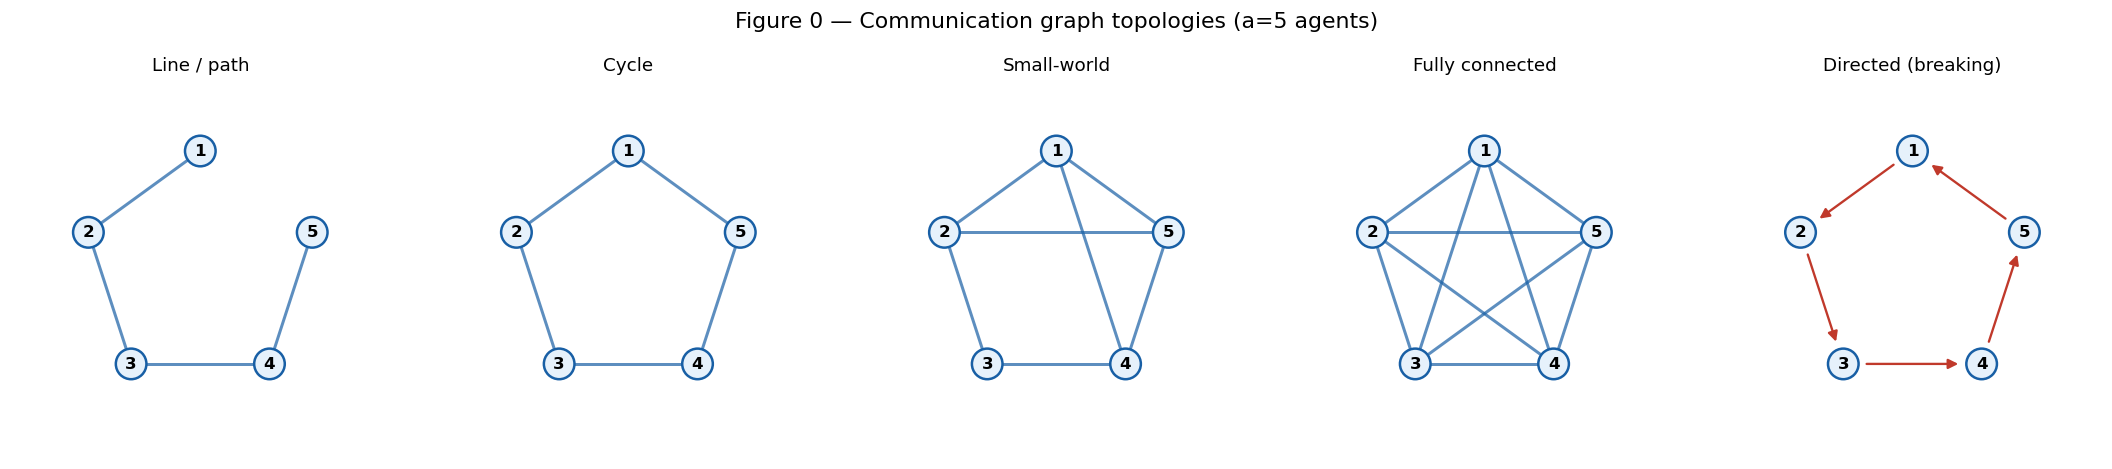

In [3]:
def draw_graph(ax, edge_list, title, directed=False, a=5):
    """Draw communication graph — pure matplotlib, no networkx."""
    angles = np.linspace(0, 2*np.pi, a, endpoint=False) + np.pi/2
    pos = {i:(np.cos(angles[i]), np.sin(angles[i])) for i in range(a)}
    for i,j in edge_list:
        xi,yi=pos[i]; xj,yj=pos[j]
        if directed:
            ax.annotate("", xy=(xj,yj), xytext=(xi,yi),
                        arrowprops=dict(arrowstyle="-|>", lw=1.4,
                                        mutation_scale=12, shrinkA=14, shrinkB=14,
                                        color="#C0392B"))
        else:
            ax.plot([xi,xj],[yi,yj],"-",lw=1.8,color="#185FA5",alpha=0.7)
    for i,(xi,yi) in pos.items():
        ax.add_patch(plt.Circle((xi,yi),0.13,facecolor="#E6F1FB",
                                 edgecolor="#185FA5",lw=1.5,zorder=3))
        ax.text(xi,yi,str(i+1),ha="center",va="center",
                fontsize=10,fontweight="bold",zorder=4)
    ax.set_xlim(-1.6,1.6); ax.set_ylim(-1.6,1.6)
    ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title,fontsize=11)

def plot_graph_topologies(a=5):
    """Plot all 5 topologies (4 undirected + 1 directed)."""
    fig, axes = plt.subplots(1,5,figsize=(18,3.8))
    configs = [
        (list(edge_map_path(a).values()),         "Line / path",     False),
        (list(edge_map_cycle(a).values()),         "Cycle",           False),
        (list(edge_map_small_world_5().values()),  "Small-world",     False),
        (list(edge_map_complete(a).values()),      "Fully connected", False),
        ([(0,1),(1,2),(2,3),(3,4),(4,0)],          "Directed (breaking)", True),
    ]
    for ax,(edges,title,directed) in zip(axes,configs):
        draw_graph(ax, edges, title, directed=directed, a=a)
    plt.suptitle("Figure 0 — Communication graph topologies (a=5 agents)", y=1.02)
    plt.tight_layout()
    savefig("fig0_graph_topologies")
    plt.show()

plot_graph_topologies()

---
# Part I — Decentralized Kernel Ridge Regression

## 1.1 Distributed Formulation

The dataset of $n = 100$ samples is divided evenly across $a = 5$ agents.
Each agent $i$ holds $n_a = 20$ observations and $m = 10$ Nyström centres are shared.
The decentralised objective is:

$$\alpha^* = \arg\min_{\alpha \in \mathbb{R}^m}
\sum_{i=1}^{a}
\underbrace{\left[
\frac{\sigma^2}{2a}\alpha^\top K_{mm}\alpha +
\frac{1}{2}\|y_i - K^{(i)}_m \alpha\|^2 +
\frac{\nu}{2a}\|\alpha\|^2
\right]}_{f_i(\alpha)}.$$

The **per-agent gradient** and **Hessian** are:

$$\nabla f_i(\alpha) = \frac{\sigma^2}{a}K_{mm}\alpha
- K^{\top}_{(i)m}\bigl(y_i - K_{(i)m}\alpha\bigr)
+ \frac{\nu}{a}\alpha, \qquad
\mathcal{H}f_i = \frac{\sigma^2}{a}K_{mm} + K^{\top}_{(i)m}K_{(i)m} + \frac{\nu}{a}I_m.$$

The global smoothness and strong-convexity constants are:
$L = \max_i \lambda_{\max}(\mathcal{H}f_i)$ and $\mu = \min_i \lambda_{\min}(\mathcal{H}f_i)$.


## 1.2 Utility functions (Part I)

In [4]:
# ──────────────────────────────────────────────────────────────────────────
# Kernel matrix  K[i,j] = exp(-||x[i] - x_approx[j]||^2)
# ──────────────────────────────────────────────────────────────────────────
def get_kernel(x, x_approx):
    n, m = len(x), len(x_approx)
    K = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            K[i, j] = np.exp(-np.linalg.norm(x[i] - x_approx[j])**2)
    return K


# ──────────────────────────────────────────────────────────────────────────
# Per-agent gradient of f_i  (see §1.1 formula above)
# ──────────────────────────────────────────────────────────────────────────
def get_grad(alpha, params_, indices, devices=None):
    K, y, sigma, nu = params_
    approx_ind, device_ind = indices
    a, m = alpha.shape
    K_mm = K[approx_ind, :]
    if devices is None:
        devices = range(a)
    grad = np.zeros((len(devices), m))
    for i_, i in enumerate(devices):
        alpha_i = alpha[i, :]
        K_Am    = K[device_ind[i], :]
        y_A     = y[device_ind[i]]
        grad[i_] = (sigma**2/a * K_mm @ alpha_i
                    - K_Am.T @ (y_A - K_Am @ alpha_i)
                    + nu/a * alpha_i)
    return grad


# ──────────────────────────────────────────────────────────────────────────
# Centralised closed-form solution  (normal equations)
# alpha* = (sigma^2 K_mm + K^T K + nu I)^{-1} K^T y
# ──────────────────────────────────────────────────────────────────────────
def exact_solution(params_, approx_ind):
    K, y, sigma, nu = params_
    m    = K.shape[1]
    K_mm = K[approx_ind, :]
    A    = sigma**2 * K_mm + K.T @ K + nu * np.eye(m)
    return np.linalg.solve(A, K.T @ y)


# ──────────────────────────────────────────────────────────────────────────
# Objective value  F(alpha)
# ──────────────────────────────────────────────────────────────────────────
def get_val(alpha_val, params_, approx_ind):
    K, y, sigma, nu = params_
    K_mm = K[approx_ind, :]
    return (sigma**2/2 * alpha_val @ K_mm @ alpha_val
            + 0.5 * np.linalg.norm(y - K @ alpha_val)**2
            + nu/2 * alpha_val @ alpha_val)


# ──────────────────────────────────────────────────────────────────────────
# Plot helpers — same style as the report figures
# ──────────────────────────────────────────────────────────────────────────
def plot_solution(alpha, x, x_approx, y=None, name='Data and reconstruction'):
    """Scatter data points + overlay the learned regression curve."""
    K_plot   = get_kernel(x, x_approx)
    y_approx = K_plot @ alpha
    if y is not None:
        plt.plot(x, y, 'o')
    plt.plot(x, y_approx, '-')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(name)
    plt.show()


def plot_error(errors, title='Error', ylabel='error'):
    """Log-log optimality-gap plot — replicates all report Error figures."""
    plt.figure()
    for name, error in errors.items():
        plt.loglog(np.arange(1, len(error)+1), error, label=name)
    plt.xlabel('iteration')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()


## 1.3 Algorithm implementations

We implement **five** decentralised algorithms.
All share the same interface: `(params, indices, lr, n_iter, metric, ...)`.

| Algorithm | Update rule (sketch) | Theoretical step-size | Directed? |
|-----------|----------------------|-----------------------|-----------|
| **DGD** | $\alpha^{t+1} = W\alpha^t - \eta\nabla f(\alpha^t)$ | $\eta < 1/L$ | ✗ requires doubly stochastic $W$ |
| **DGT** | gradient tracker $g^t$ removes consensus bias | $\eta < (1-\rho(W))/L$ | ✗ requires symmetric $W$ |
| **DD** | dual ascent on $\lambda$, inner GD on $\alpha$ | $\eta \leq 2\mu/\sigma_{\max}^2(A)$ | ✗ |
| **ADMM** | augmented Lagrangian with consensus variable $z$ | $\beta$ large | ✗ |
| **DGD + Push-Sum** | weight-normalised DGD on column-stochastic $A$ | $\eta < (1-\rho_2(A))/L$ | ✓ any strongly-connected directed graph |

> **Why DGD fails on directed graphs.**  
> Standard DGD requires $W$ doubly stochastic (row *and* column sums = 1) to ensure that the network average $\bar\alpha^t = \tfrac{1}{a}\sum_i\alpha_i^t$ is preserved at each step.  
> With a directed (column-stochastic only) mixing matrix, the average drifts and DGD converges to a *biased* point.
>
> **Push-Sum fixes this** by maintaining an auxiliary weight vector $w_i^t$ that tracks each agent's share of the total "mass", and using the de-biased estimate $\tilde\alpha_i^t = x_i^t / w_i^t$ for gradient evaluation.

In [5]:
# ══════════════════════════════════════════════════════════════════════════
# 1. Decentralised Gradient Descent  (DGD)
# ══════════════════════════════════════════════════════════════════════════
def DGD(params, indices, lr=0.0001, n_iter=1000, metric='gap',
        packageloss=0., asynch=0.):
    """
    DGD update:  alpha^{t+1} = W @ alpha^t  -  lr * grad_f(alpha^t)

    With a *constant* step-size, DGD converges to a neighbourhood of alpha*
    (consensus bias proportional to lr).  Exact convergence requires a
    diminishing step-size.

    Parameters
    ----------
    params      : (W, K, y, sigma, nu)
    indices     : (approx_ind, device_ind)
    lr          : constant learning rate  (must satisfy lr < 1/L)
    metric      : 'gap' -> ||mean(alpha_t) - alpha*||, 'val' -> F(alpha_t)
    packageloss : fraction of agents whose gradient is silently dropped
    asynch      : fraction of agents that reuse their previous gradient
    """
    m = params[1].shape[1]
    a = len(indices[1])
    W, params_ = params[0], params[1:]

    alpha = np.zeros((a, m))
    for i in range(a):
        alpha[i] = np.random.rand(m)

    error = np.zeros(n_iter)
    if metric == 'gap':
        alpha_exact = exact_solution(params_, indices[0])

    for k in range(n_iter):
        grad_new = get_grad(alpha, params_, indices)

        # ── communication failures ──────────────────────────────────────
        drop = np.random.choice(a, int(packageloss * a), replace=False)
        grad_new[drop] = 0.
        if k > 0:
            idx = np.random.choice(a, int(asynch * a), replace=False)
            grad_new[idx] = grad[idx]
        grad = grad_new
        # ────────────────────────────────────────────────────────────────

        alpha = W @ alpha - lr * grad

        alpha_mean = np.mean(alpha, axis=0)
        error[k] = (np.linalg.norm(alpha_mean - alpha_exact) if metric == 'gap'
                    else get_val(alpha_mean, params_, indices[0]))

        if k % (n_iter // 20) == 0:
            print(f'DGD  it={k:6d}  error={error[k]:.4e}')

    return alpha, error


# ══════════════════════════════════════════════════════════════════════════
# 2. Gradient Tracking  (DGT / DIGing)
# ══════════════════════════════════════════════════════════════════════════
def DGT(params, indices, lr=0.0001, n_iter=1000, metric='gap',
        packageloss=0., asynch=0.):
    """
    DGT introduces an auxiliary variable g that tracks the average gradient:

        alpha^{t+1} = W @ alpha^t  -  lr * g^t
        g^{t+1}     = W @ g^t  +  grad(alpha^{t+1})  -  grad(alpha^t)

    Unlike DGD, DGT achieves *exact* linear convergence with a constant
    step-size because the gradient tracker eliminates the consensus error.
    """
    m = params[1].shape[1]
    a = len(indices[1])
    W, params_ = params[0], params[1:]

    alpha = np.zeros((a, m))
    for i in range(a):
        alpha[i] = np.random.rand(m)
    g = get_grad(alpha, params_, indices)

    error = np.zeros(n_iter)
    if metric == 'gap':
        alpha_exact = exact_solution(params_, indices[0])

    for k in range(n_iter):
        alpha_curr    = W @ alpha - lr * g
        grad_new      = get_grad(alpha,      params_, indices)
        grad_curr_new = get_grad(alpha_curr, params_, indices)

        drop = np.random.choice(a, int(packageloss * a), replace=False)
        grad_new[drop]      = 0.
        grad_curr_new[drop] = 0.
        if k > 0:
            idx = np.random.choice(a, int(asynch * a), replace=False)
            grad_new[idx]      = grad[idx]
            grad_curr_new[idx] = grad_curr[idx]
        grad, grad_curr = grad_new, grad_curr_new

        g     = W @ g + (grad_curr - grad)
        alpha = alpha_curr

        alpha_mean = np.mean(alpha, axis=0)
        error[k] = (np.linalg.norm(alpha_mean - alpha_exact) if metric == 'gap'
                    else get_val(alpha_mean, params_, indices[0]))

        if k % (n_iter // 20) == 0:
            print(f'DGT  it={k:6d}  error={error[k]:.4e}')

    return alpha, error


# ══════════════════════════════════════════════════════════════════════════
# 3. Dual Decomposition  (DD)
# ══════════════════════════════════════════════════════════════════════════
def DD(params, indices, lr=0.0001, n_iter=1000,
       lr_sub=1e-3, n_iter_sub=100, metric='gap'):
    """
    DD dualises the consensus constraint alpha_i = alpha_j for each edge (i,j).
    Outer loop : dual gradient ascent on lambda  (step lr).
    Inner loop : n_iter_sub GD steps on each agent's primal sub-problem.

    Theoretical step-size bound: lr  <=  2*mu / sigma_max(A)^2
    where A is the edge-incidence matrix and mu is the strong-convexity constant.
    """
    m = params[1].shape[1]
    a = len(indices[1])
    Edge_map, params_ = params[0], params[1:]

    Prev = {i: [] for i in range(a)}
    Next = {i: [] for i in range(a)}
    for edge, nodes in Edge_map.items():
        Prev[nodes[0]].append(edge)
        Next[nodes[1]].append(edge)

    lam   = {e: np.zeros(m) for e in Edge_map}
    alpha = np.array([np.random.rand(m) for _ in range(a)])

    error = np.zeros(n_iter)
    if metric == 'gap':
        alpha_exact = exact_solution(params_, indices[0])

    for k in range(n_iter):
        # ── primal update (inner GD) ────────────────────────────────────
        for i in range(a):
            for _ in range(n_iter_sub):
                g_i  = get_grad(alpha, params_, indices, [i])
                dual = (sum(lam[e] for e in Prev[i])
                        - sum(lam[e] for e in Next[i]))
                alpha[[i]] -= lr_sub * (g_i + dual)

        # ── dual update (gradient ascent) ───────────────────────────────
        for edge, nodes in Edge_map.items():
            lam[edge] += lr * (alpha[nodes[0]] - alpha[nodes[1]])

        alpha_mean = np.mean(alpha, axis=0)
        error[k] = (np.linalg.norm(alpha_mean - alpha_exact) if metric == 'gap'
                    else get_val(alpha_mean, params_, indices[0]))

        if k % (n_iter // 20) == 0:
            print(f'DD   it={k:6d}  error={error[k]:.4e}')

    return alpha, error


# ══════════════════════════════════════════════════════════════════════════
# 4. ADMM
# ══════════════════════════════════════════════════════════════════════════
def ADMM(params, indices, lr=0.0001, n_iter=1000,
         lr_sub=1e-3, n_iter_sub=100, BETA=100, metric='gap'):
    """
    ADMM augments the Lagrangian with a proximal term:

        L_beta = sum_i f_i(alpha_i)
               + sum_{(i,j)} [ lambda_{ij}' (alpha_i - z_{ij})
                               + beta/2 ||alpha_i - z_{ij}||^2 ]

    where z_{ij} = (alpha_i + alpha_j)/2 is the consensus variable.
    Larger BETA enforces consensus faster but may slow primal convergence.
    """
    m = params[1].shape[1]
    a = len(indices[1])
    Edge_map, params_ = params[0], params[1:]

    Prev = {i: [] for i in range(a)}
    Next = {i: [] for i in range(a)}
    for edge, nodes in Edge_map.items():
        Prev[nodes[0]].append(edge)
        Next[nodes[1]].append(edge)

    lam   = {e: np.zeros(m) for e in Edge_map}
    y_    = {e: np.zeros(m) for e in Edge_map}
    alpha = np.array([np.random.rand(m) for _ in range(a)])

    error = np.zeros(n_iter)
    if metric == 'gap':
        alpha_exact = exact_solution(params_, indices[0])

    for k in range(n_iter):
        # Note: do NOT reset alpha here — we continue from the previous iterate
        for i in range(a):
            for _ in range(n_iter_sub):
                g_i = (1/BETA * get_grad(alpha, params_, indices, [i])
                       + sum(lam[e]/BETA - y_[e] + alpha[i] for e in Prev[i])
                       + sum(-lam[e]/BETA - y_[e] + alpha[i] for e in Next[i]))
                alpha[[i]] -= lr_sub * BETA * g_i

        for edge, nodes in Edge_map.items():
            y_[edge]   = (alpha[nodes[0]] + alpha[nodes[1]]) / 2.
            lam[edge] += BETA * (alpha[nodes[0]] - y_[edge])

        alpha_mean = np.mean(alpha, axis=0)
        error[k] = (np.linalg.norm(alpha_mean - alpha_exact) if metric == 'gap'
                    else get_val(alpha_mean, params_, indices[0]))

        if k % (n_iter // 20) == 0:
            print(f'ADMM it={k:6d}  error={error[k]:.4e}')

    return alpha, error


## 1.4 Dataset and problem setup

The full dataset contains **one million** $(x_i, y_i)$ pairs.
We work with the first $n = 100$ points, choose $m = \lfloor\sqrt{n}\rfloor = 10$
Nyström centres at random, and split the data evenly across $a = 5$ agents.


Dataset: 1,000,000 points, x in [-1.45, 1.45]
  [saved] fig1_data.pdf  +  fig1_data.png


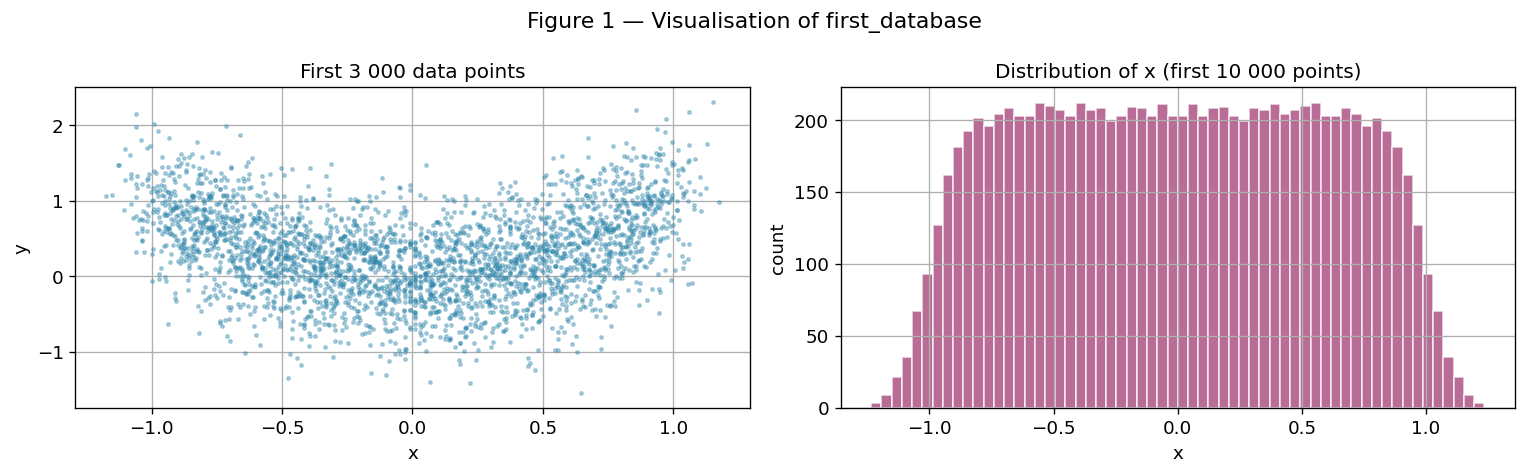

In [6]:
np.random.seed(42)

# ── Load data ──────────────────────────────────────────────────────────────
with open("first_database.pkl","rb") as f:
    x_full, y_full = pickle.load(f)
x_full = np.asarray(x_full); y_full = np.asarray(y_full)
print(f"Dataset: {len(x_full):,} points, x in [{x_full.min():.2f}, {x_full.max():.2f}]")

fig, axes = plt.subplots(1,2,figsize=(13,4))
axes[0].plot(x_full[:3000], y_full[:3000],"o",ms=2,alpha=0.35,color="#2E86AB")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_title("First 3 000 data points")
axes[1].hist(x_full[:10000],bins=60,color="#A23B72",alpha=0.75,edgecolor="white")
axes[1].set_xlabel("x"); axes[1].set_ylabel("count")
axes[1].set_title("Distribution of x (first 10 000 points)")
plt.suptitle("Figure 1 — Visualisation of first_database")
plt.tight_layout(); savefig("fig1_data"); plt.show()


## 1.4b Problem setup — parameters, kernel matrices, agent partition

We fix the global constants for Part I: $n=100$ data points, $m=10$ Nyström
landmarks ($m \approx \sqrt{n}$), $a=5$ agents with 20 points each,
noise level $\sigma=0.5$, and regularisation $\nu=1$.


In [7]:
# ── Problem hyperparameters ────────────────────────────────────────────────
n      = 100    # total number of training samples used
m      = 10     # Nystrom approximation size  (≈ sqrt(n))
a      = 5      # number of agents / workers
sigma  = 0.5    # noise standard deviation (given in the project)
nu     = 1.0    # ridge regularisation parameter
metric = 'gap'  # error metric: 'gap' = ||alpha_bar_t - alpha*||

# ── Select the first n data points ────────────────────────────────────────
x = x_full[:n]   # features,  shape (n,)
y = y_full[:n]   # labels,    shape (n,)

# ── Choose m Nystrom landmark indices uniformly at random ─────────────────
sel        = list(range(n))
approx_ind = np.random.choice(sel, m, replace=False)  # landmark indices in [0, n)
x_approx   = x[approx_ind]                            # landmark positions, shape (m,)

# ── Partition n points evenly across a agents (20 points each) ────────────
n_a        = n // a                                    # points per agent
device_ind = np.array(sel).reshape(a, n_a)            # shape (a, n_a)
indices    = (approx_ind, device_ind)                  # passed to all algorithms

# ── Build kernel matrix K of shape (n, m) ─────────────────────────────────
# K[i, j] = exp(-||x[i] - x_approx[j]||^2)   (RBF / Euclidean kernel)
K = get_kernel(x, x_approx)

print(f"Setup: n={n}, m={m}, a={a}, n_a={n_a}")
print(f"K shape: {K.shape}  (expected ({n}, {m}))")


Setup: n=100, m=10, a=5, n_a=20
K shape: (100, 10)  (expected (100, 10))


## 1.5 Communication graphs and theoretical step-size bounds

We test **four** graph topologies: line, small-world, fully-connected, and directed.
The mixing matrix $W$ is derived from the Laplacian as
$W = I - \frac{1}{1+\lambda_{\max}(L)}L$.

The **smoothness constant** $L = \max_i \lambda_{\max}(\mathcal{H}f_i)$
sets the maximum admissible step-size: $\eta < 1/L$.

The **DD step-size bound** is $\eta < 2\mu/\sigma_{\max}^2(A)$
where $A$ is the edge-incidence matrix.


In [8]:
# ── Edge maps for DD / ADMM ────────────────────────────────────────────────
Edge_map_full = {}
num = 0
for i in range(a):
    for j in range(a):
        if i < j:
            num += 1
            Edge_map_full[num] = (i, j)

Edge_map_sw = {0:(0,1), 1:(1,2), 2:(2,3), 3:(3,4),
               4:(0,4), 5:(0,3), 6:(1,4)}

Edge_map_line = {i: (i, i+1) for i in range(a-1)}

# ── Mixing matrices for DGD / DGT ─────────────────────────────────────────
def laplacian_to_W(L):
    # Use the largest eigenvalue (spectral norm) — guarantees W doubly stochastic
    tau = 1.0 / (1.0 + float(np.linalg.eigvalsh(L)[-1]))
    return np.eye(L.shape[0]) - tau * L

L_full = np.full((a, a), -1.); np.fill_diagonal(L_full, a-1)
W_full = laplacian_to_W(L_full)

W_sw   = laplacian_to_W(np.array([[ 3,-1, 0,-1,-1],
                                   [-1, 3,-1, 0,-1],
                                   [ 0,-1, 2,-1, 0],
                                   [-1, 0,-1, 3,-1],
                                   [-1,-1, 0,-1, 3]]))

W_line = laplacian_to_W(np.array([[ 1,-1, 0, 0, 0],
                                   [-1, 2,-1, 0, 0],
                                   [ 0,-1, 2,-1, 0],
                                   [ 0, 0,-1, 2,-1],
                                   [ 0, 0, 0,-1, 1]]))

# Directed matrix: row-stochastic but NOT doubly stochastic
# This deliberately breaks the symmetry assumption of DGD/DGT
W_dir  = np.array([[0.5, 0.5, 0.0, 0.0, 0.0],
                    [0.0, 0.5, 0.5, 0.0, 0.0],
                    [0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.5, 0.5],
                    [0.5, 0.0, 0.0, 0.0, 0.5]], dtype=float)

Edge_map_vals = {'full': Edge_map_full, 'small world': Edge_map_sw,
                 'line': Edge_map_line}
W_vals        = {'directed': W_dir, 'line': W_line,
                 'small world': W_sw, 'full': W_full}

# ── Theoretical constants ──────────────────────────────────────────────────
K_mm   = K[approx_ind, :]
L_list, m_list = [], []
for i in range(a):
    K_Am = K[device_ind[i], :]
    H_i  = sigma**2/a * K_mm + K_Am.T @ K_Am + nu/a * np.eye(m)
    ev, _ = np.linalg.eig(H_i)
    L_list.append(np.max(ev).real)
    m_list.append(np.min(ev).real)

L_smooth  = np.max(L_list)
mu_strong = np.min(m_list)
print(f'Smoothness L        = {L_smooth:.4f}  →  max step-size DGD/DGT: {1/L_smooth:.5f}')
print(f'Strong convexity mu = {mu_strong:.4f}')

# DD step-size bound via edge-incidence matrix B (blocks of size m, not n_a)
# B has shape (|E|*m, a*m); sigma_max^2(B) = lambda_max(B.T @ B)
_E_line = len(Edge_map_line)   # number of edges in the line graph
B_mat = np.zeros((_E_line * m, a * m))
for row_e, (i, j) in Edge_map_line.items():
    sl = slice(row_e * m, (row_e + 1) * m)
    B_mat[sl, i*m:(i+1)*m] =  np.eye(m)
    B_mat[sl, j*m:(j+1)*m] = -np.eye(m)
sig_A2 = float(np.linalg.eigvalsh(B_mat.T @ B_mat)[-1])
print(f'sigma_max^2(B) line graph    = {sig_A2:.5f}')
print(f'Max step-size DD (line)      = {2*mu_strong/sig_A2:.5f}')


Smoothness L        = 126.1391  →  max step-size DGD/DGT: 0.00793
Strong convexity mu = 0.2000
sigma_max^2(B) line graph    = 3.61803
Max step-size DD (line)      = 0.11056


## 1.6 Centralized solution (ground-truth $\alpha^*$)

We first compute $\alpha^*$ analytically and plot the resulting regression
curve (Figure 2a in the report).


Exact solution alpha* = [ 0.7053 -0.4461  0.0291 -0.4317 -0.4197 -0.3306  0.1878  0.541   0.5402
  0.7104]
Objective F(alpha*)   = 14.895237


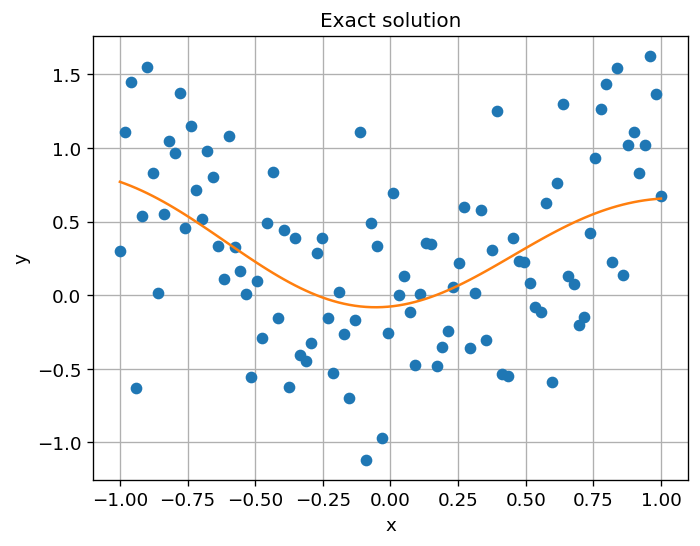

In [9]:
params_c  = (K, y, sigma, nu)
alpha_star = exact_solution(params_c, approx_ind)

print('Exact solution alpha* =', alpha_star.round(4))
print('Objective F(alpha*)   =', get_val(alpha_star, params_c, approx_ind).round(6))

# Figure 2a — exact solution
plot_solution(alpha_star, x, x_approx, y, name='Exact solution')


## 1.7 Running all four algorithms — function approximation (Figure 2)

We fix the graph to **line** for the visual comparison of function
approximations, consistent with §1.4 of the report.


DGD  it=     0  error=1.7584e+00
DGD  it=  1000  error=3.4076e-01
DGD  it=  2000  error=1.9746e-01
DGD  it=  3000  error=1.3668e-01
DGD  it=  4000  error=1.0258e-01
DGD  it=  5000  error=8.3755e-02
DGD  it=  6000  error=7.4059e-02
DGD  it=  7000  error=6.9407e-02
DGD  it=  8000  error=6.7292e-02
DGD  it=  9000  error=6.6366e-02
DGD  it= 10000  error=6.5974e-02
DGD  it= 11000  error=6.5815e-02
DGD  it= 12000  error=6.5754e-02
DGD  it= 13000  error=6.5734e-02
DGD  it= 14000  error=6.5729e-02
DGD  it= 15000  error=6.5730e-02
DGD  it= 16000  error=6.5732e-02
DGD  it= 17000  error=6.5734e-02
DGD  it= 18000  error=6.5736e-02
DGD  it= 19000  error=6.5738e-02
DGT  it=     0  error=1.8429e+00
DGT  it=  1000  error=1.6463e-01
DGT  it=  2000  error=6.9672e-02
DGT  it=  3000  error=4.5861e-02
DGT  it=  4000  error=3.0716e-02
DGT  it=  5000  error=2.0582e-02
DGT  it=  6000  error=1.3791e-02
DGT  it=  7000  error=9.2414e-03
DGT  it=  8000  error=6.1927e-03
DGT  it=  9000  error=4.1498e-03
DGT  it= 1

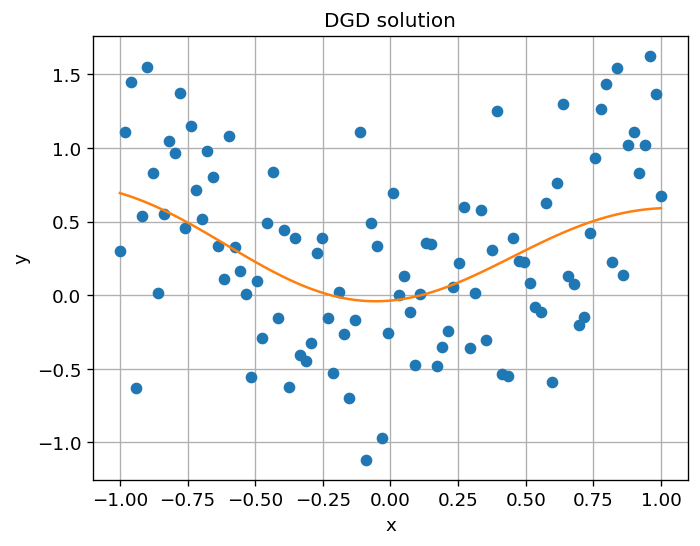

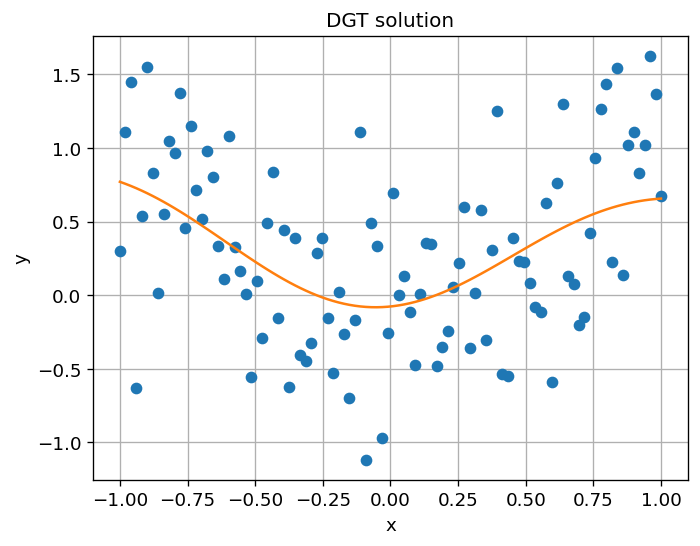

DGD  it=     0  error=1.9288e+00
DGD  it=  1000  error=4.6344e-01
DGD  it=  2000  error=2.7523e-01
DGD  it=  3000  error=1.9491e-01
DGD  it=  4000  error=1.5136e-01
DGD  it=  5000  error=1.2777e-01
DGD  it=  6000  error=1.1553e-01
DGD  it=  7000  error=1.0941e-01
DGD  it=  8000  error=1.0641e-01
DGD  it=  9000  error=1.0493e-01
DGD  it= 10000  error=1.0419e-01
DGD  it= 11000  error=1.0381e-01
DGD  it= 12000  error=1.0361e-01
DGD  it= 13000  error=1.0350e-01
DGD  it= 14000  error=1.0344e-01
DGD  it= 15000  error=1.0340e-01
DGD  it= 16000  error=1.0338e-01
DGD  it= 17000  error=1.0337e-01
DGD  it= 18000  error=1.0336e-01
DGD  it= 19000  error=1.0335e-01
DGT  it=     0  error=1.7290e+00
DGT  it=  1000  error=2.8991e-01
DGT  it=  2000  error=1.7195e-01
DGT  it=  3000  error=1.1420e-01
DGT  it=  4000  error=7.6096e-02
DGT  it=  5000  error=5.0723e-02
DGT  it=  6000  error=3.3820e-02
DGT  it=  7000  error=2.2555e-02
DGT  it=  8000  error=1.5047e-02
DGT  it=  9000  error=1.0040e-02
DGT  it= 1

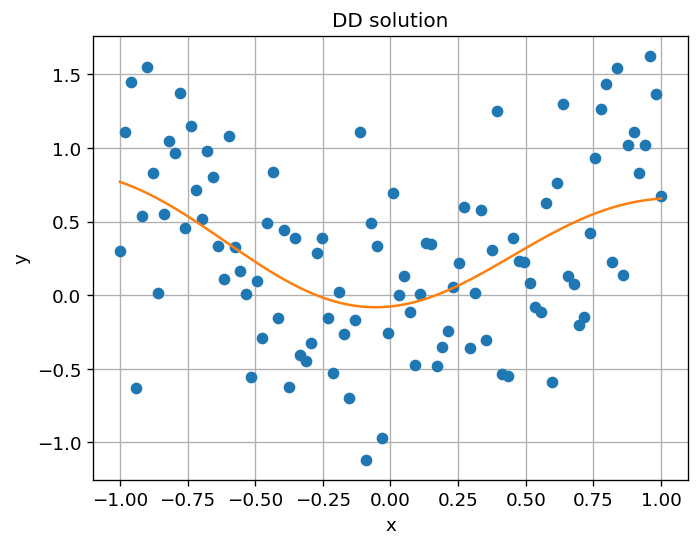

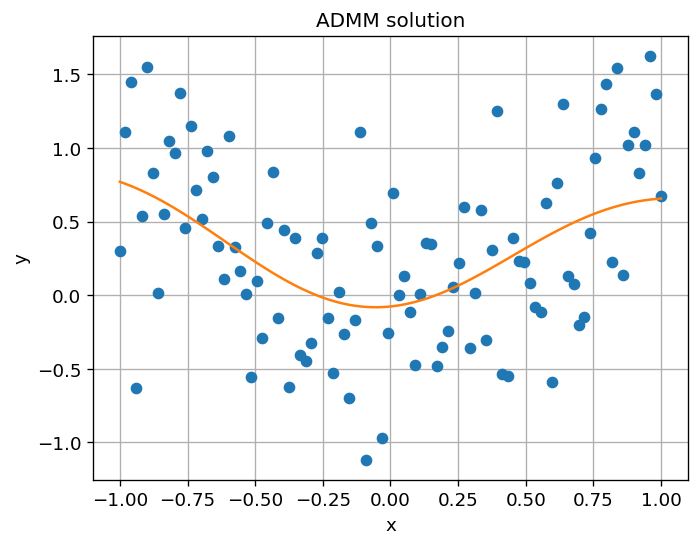

In [10]:
error_vals_graph  = {}   # {graph: (err_DGD, err_DGT, err_DD, err_ADMM)}
error_vals_method = {}   # populated on the 'line' graph

# ══ DGD and DGT — all four W matrices ═════════════════════════════════════
for name, W in W_vals.items():
    params  = (W, K, y, sigma, nu)
    lr      = 2e-3
    n_iter  = 20000
    alpha_DGD, error_DGD = DGD(params, indices, lr=lr, n_iter=n_iter, metric=metric)
    alpha_DGT, error_DGT = DGT(params, indices, lr=lr, n_iter=n_iter, metric=metric)
    error_vals_graph[name] = (error_DGD, error_DGT)

    if name == 'line':
        alpha_DGD_ = np.mean(alpha_DGD, axis=0)
        alpha_DGT_ = np.mean(alpha_DGT, axis=0)
        # Figure 2b and 2c
        plot_solution(alpha_DGD_, x, x_approx, y, name='DGD solution')
        plot_solution(alpha_DGT_, x, x_approx, y, name='DGT solution')
        error_vals_method['DGD'] = error_DGD
        error_vals_method['DGT'] = error_DGT

# ══ DD and ADMM — all three Edge_maps ═════════════════════════════════════
for name, Edge_map in Edge_map_vals.items():
    # Dual Decomposition
    params    = (Edge_map, K, y, sigma, nu)
    alpha_DD, error_DD = DD(params, indices, lr=0.1, n_iter=20000,
                            lr_sub=1e-3, n_iter_sub=50, metric=metric)
    # ADMM
    alpha_ADMM, error_ADMM = ADMM(params, indices, lr=0.1, n_iter=20001,
                                  lr_sub=1e-3, n_iter_sub=100, BETA=100,
                                  metric=metric)
    if name in error_vals_graph:
        error_vals_graph[name] += (error_DD, error_ADMM)
    else:
        error_vals_graph[name] = (error_DD, error_ADMM)

    if name == 'line':
        alpha_DD_   = np.mean(alpha_DD,   axis=0)
        alpha_ADMM_ = np.mean(alpha_ADMM, axis=0)
        # Figure 2d and 2e
        plot_solution(alpha_DD_,   x, x_approx, y, name='DD solution')
        plot_solution(alpha_ADMM_, x, x_approx, y, name='ADMM solution')
        error_vals_method['DD']   = error_DD
        error_vals_method['ADMM'] = error_ADMM


## 1.8 Convergence analysis — Figure 3

We compare the four methods on the line graph in log-log scale.

> **Expected behaviour:** DGT converges exactly at a linear rate; DGD
> plateaus due to consensus bias; DD and ADMM achieve higher accuracy,
> with ADMM reaching machine precision fastest.


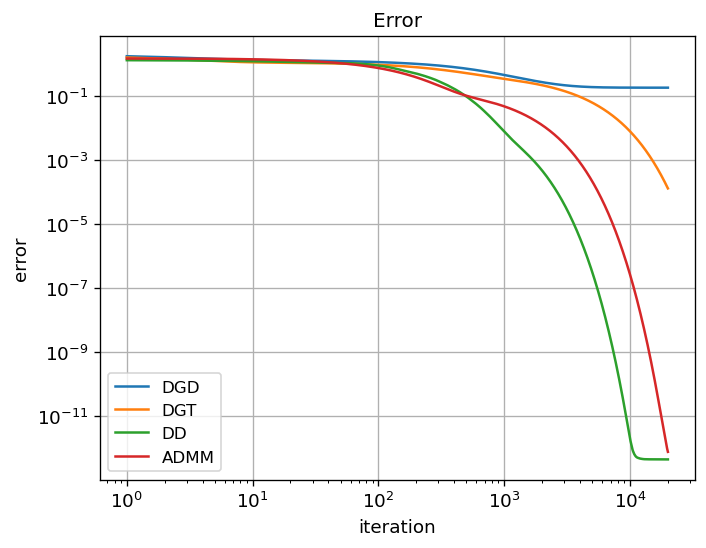

<Figure size 768x576 with 0 Axes>

In [11]:
# Figure 3 — all methods on the same graph
plot_error(error_vals_method, title='Error', ylabel='error')
plt.savefig('fig3_convergence.pdf')


## 1.9 Influence of the communication graph — Figure 4

Four topologies: directed, line, small-world, fully-connected.

> **Expected behaviour:** fully-connected is fastest (largest spectral gap);
> directed communication diverges due to broken doubly-stochastic property.


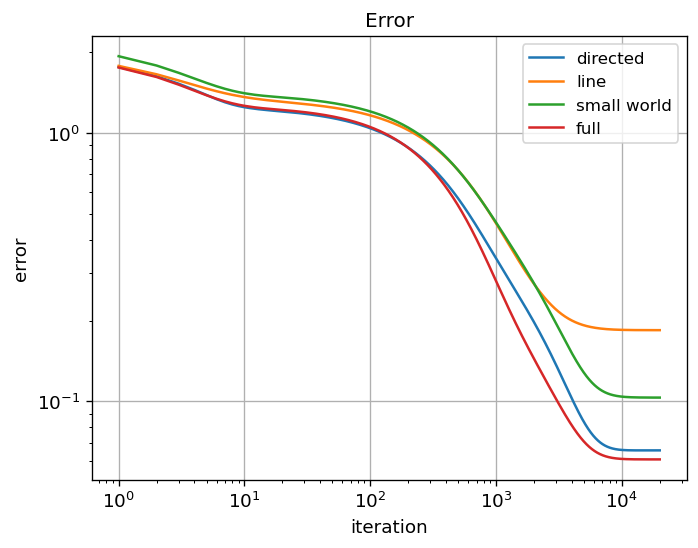

<Figure size 768x576 with 0 Axes>

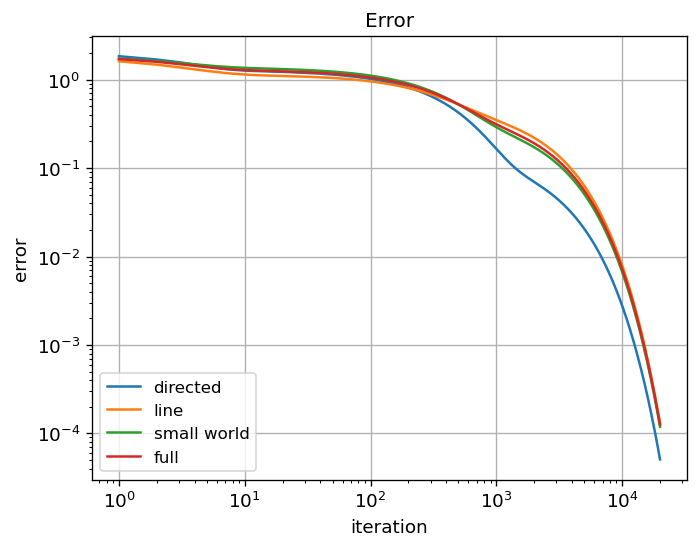

<Figure size 768x576 with 0 Axes>

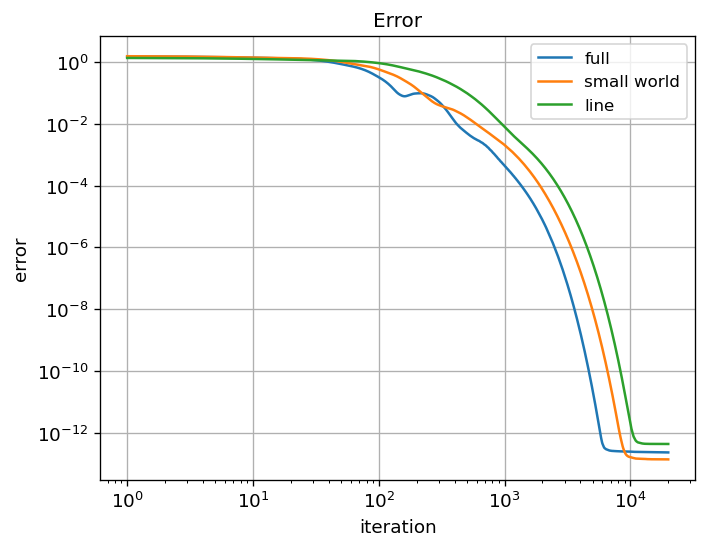

<Figure size 768x576 with 0 Axes>

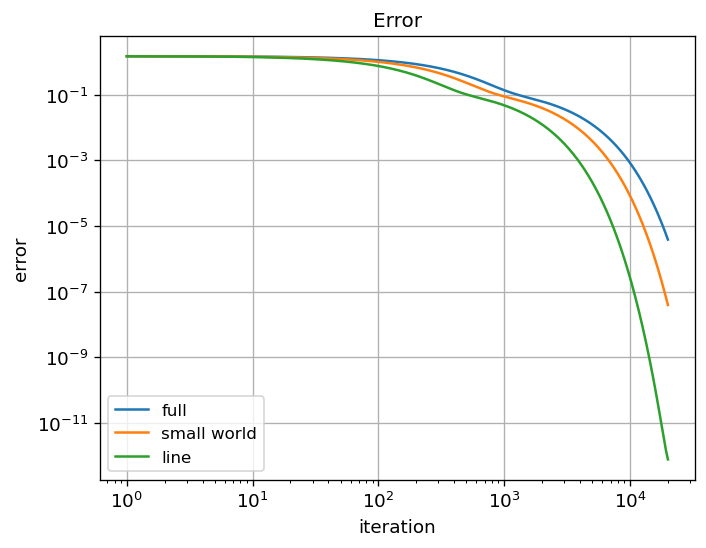

<Figure size 768x576 with 0 Axes>

In [12]:
# Figure 4a — DGD
plot_error({n: error_vals_graph[n][0] for n in W_vals}, title='Error')
plt.savefig('fig4a_DGD_graphs.pdf')

# Figure 4b — DGT
plot_error({n: error_vals_graph[n][1] for n in W_vals}, title='Error')
plt.savefig('fig4b_DGT_graphs.pdf')

# Figure 4c — DD  (only Edge_map topologies)
plot_error({n: error_vals_graph[n][-2] for n in Edge_map_vals}, title='Error')
plt.savefig('fig4c_DD_graphs.pdf')

# Figure 4d — ADMM
plot_error({n: error_vals_graph[n][-1] for n in Edge_map_vals}, title='Error')
plt.savefig('fig4d_ADMM_graphs.pdf')


## 1.10 Robustness to communication failures — Figure 5

We introduce two types of perturbation over the **fully-connected** graph:
- **Packet loss** — gradient silently zeroed for a random fraction of agents.
- **Asynchrony** — a fraction of agents reuse their previous (stale) gradient.

Tested at 0%, 40%, 80%.


DGD  it=     0  error=1.7526e+00
DGD  it=  1000  error=3.0765e-01
DGD  it=  2000  error=1.6378e-01
DGD  it=  3000  error=1.1450e-01
DGD  it=  4000  error=8.8638e-02
DGD  it=  5000  error=7.4716e-02
DGD  it=  6000  error=6.7557e-02
DGD  it=  7000  error=6.4044e-02
DGD  it=  8000  error=6.2367e-02
DGD  it=  9000  error=6.1575e-02
DGD  it= 10000  error=6.1201e-02
DGD  it= 11000  error=6.1021e-02
DGD  it= 12000  error=6.0933e-02
DGD  it= 13000  error=6.0889e-02
DGD  it= 14000  error=6.0866e-02
DGD  it= 15000  error=6.0854e-02
DGD  it= 16000  error=6.0847e-02
DGD  it= 17000  error=6.0843e-02
DGD  it= 18000  error=6.0840e-02
DGD  it= 19000  error=6.0839e-02
DGT  it=     0  error=1.6975e+00
DGT  it=  1000  error=3.4641e-01
DGT  it=  2000  error=2.1686e-01
DGT  it=  3000  error=1.4285e-01
DGT  it=  4000  error=9.4263e-02
DGT  it=  5000  error=6.2237e-02
DGT  it=  6000  error=4.1113e-02
DGT  it=  7000  error=2.7173e-02
DGT  it=  8000  error=1.7969e-02
DGT  it=  9000  error=1.1888e-02
DGT  it= 1

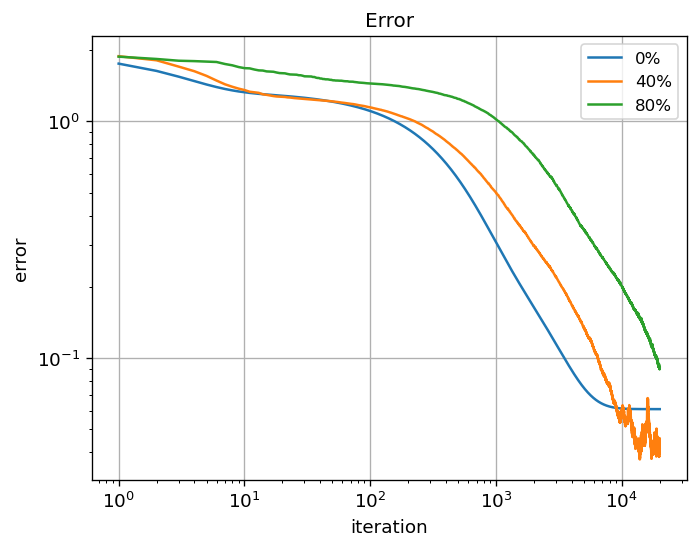

<Figure size 768x576 with 0 Axes>

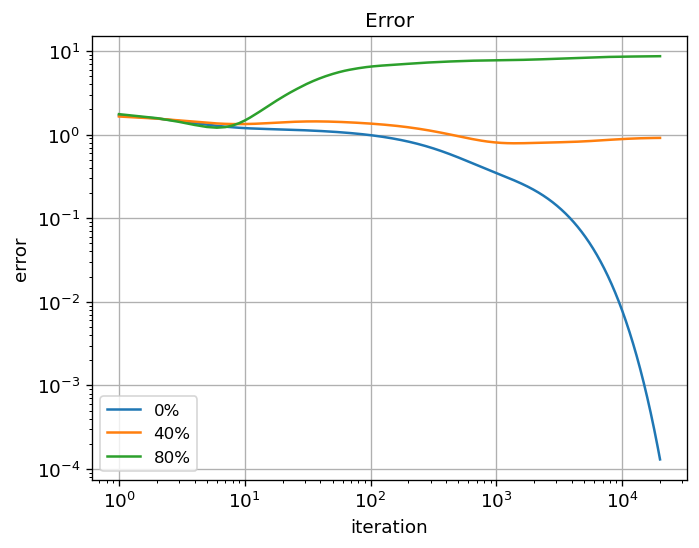

DGD  it=     0  error=1.7226e+00
DGD  it=  1000  error=2.8920e-01
DGD  it=  2000  error=1.5870e-01
DGD  it=  3000  error=1.1171e-01
DGD  it=  4000  error=8.6932e-02
DGD  it=  5000  error=7.3684e-02
DGD  it=  6000  error=6.6946e-02
DGD  it=  7000  error=6.3682e-02
DGD  it=  8000  error=6.2151e-02
DGD  it=  9000  error=6.1444e-02
DGD  it= 10000  error=6.1119e-02
DGD  it= 11000  error=6.0969e-02
DGD  it= 12000  error=6.0900e-02
DGD  it= 13000  error=6.0867e-02
DGD  it= 14000  error=6.0852e-02
DGD  it= 15000  error=6.0844e-02
DGD  it= 16000  error=6.0841e-02
DGD  it= 17000  error=6.0839e-02
DGD  it= 18000  error=6.0838e-02
DGD  it= 19000  error=6.0837e-02
DGD  it= 20000  error=6.0837e-02
DGT  it=     0  error=1.6940e+00
DGT  it=  1000  error=4.1242e-01
DGT  it=  2000  error=2.6467e-01
DGT  it=  3000  error=1.7666e-01
DGT  it=  4000  error=1.1804e-01
DGT  it=  5000  error=7.8885e-02
DGT  it=  6000  error=5.2726e-02
DGT  it=  7000  error=3.5245e-02
DGT  it=  8000  error=2.3563e-02
DGT  it=  

<Figure size 768x576 with 0 Axes>

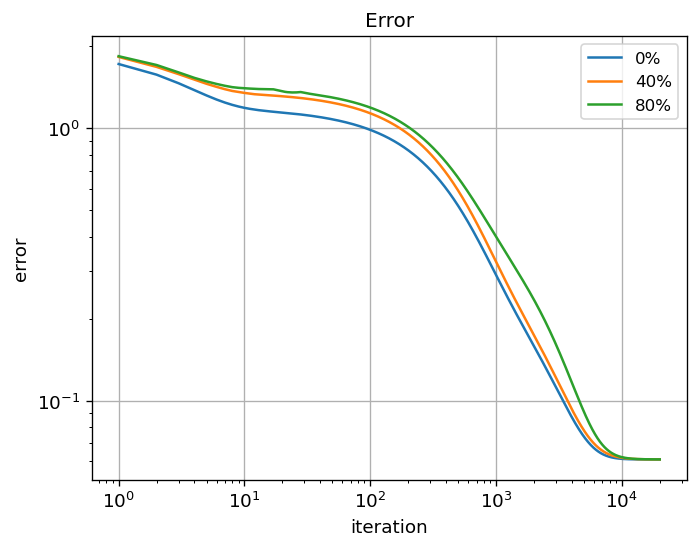

<Figure size 768x576 with 0 Axes>

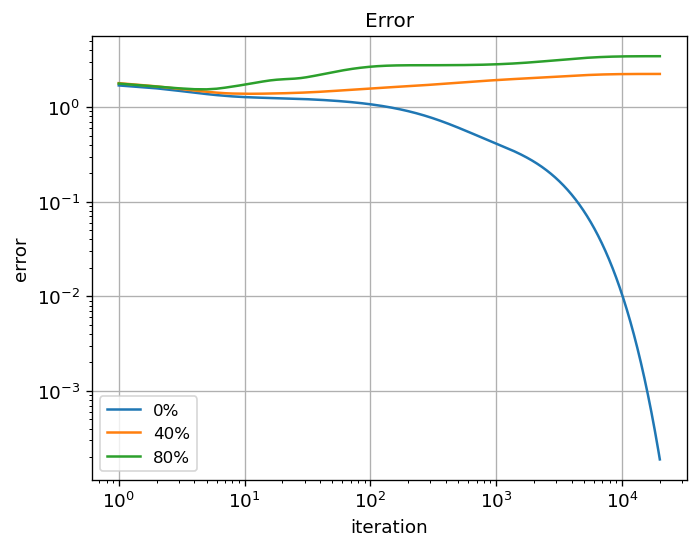

<Figure size 768x576 with 0 Axes>

In [13]:
# ── Packet loss ────────────────────────────────────────────────────────────
packagelosses       = [0., 0.4, 0.8]
error_vals_package  = {}
for pkgloss in packagelosses:
    params = (W_full, K, y, sigma, nu)
    _, err_DGD = DGD(params, indices, lr=2e-3, n_iter=20000, metric=metric,
                     packageloss=pkgloss, asynch=0.)
    _, err_DGT = DGT(params, indices, lr=2e-3, n_iter=20000, metric=metric,
                     packageloss=pkgloss, asynch=0.)
    key = str(int(pkgloss * 100)) + '%'
    error_vals_package[key] = (err_DGD, err_DGT)

# Figure 5a — DGD with packet loss
plot_error({k: v[0] for k, v in error_vals_package.items()}, title='Error')
plt.savefig('fig5a_DGD_packageloss.pdf')

# Figure 5b — DGT with packet loss
plot_error({k: v[1] for k, v in error_vals_package.items()}, title='Error')
plt.savefig('fig5b_DGT_packageloss.pdf')

# ── Asynchrony ─────────────────────────────────────────────────────────────
asynchs            = [0., 0.4, 0.8]
error_vals_asynch  = {}
for asynch_v in asynchs:
    params = (W_full, K, y, sigma, nu)
    _, err_DGD = DGD(params, indices, lr=2e-3, n_iter=20001, metric=metric,
                     packageloss=0., asynch=asynch_v)
    _, err_DGT = DGT(params, indices, lr=2e-3, n_iter=20001, metric=metric,
                     packageloss=0., asynch=asynch_v)
    key = str(int(asynch_v * 100)) + '%'
    error_vals_asynch[key] = (err_DGD, err_DGT)

# Figure 5c — DGD with asynchrony
plot_error({k: v[0] for k, v in error_vals_asynch.items()}, title='Error')
plt.savefig('fig5c_DGD_asynch.pdf')

# Figure 5d — DGT with asynchrony
plot_error({k: v[1] for k, v in error_vals_asynch.items()}, title='Error')
plt.savefig('fig5d_DGT_asynch.pdf')


## 1.11 Function approximation on a test grid — Figure 6

We evaluate the learned $\alpha$ on $n_t = 250$ uniformly spaced points in $[-1, 1]$.

> All methods recover a similar smooth curve, confirming they minimise the
> same objective.  DGT, DD, and ADMM produce slightly sharper reconstructions.


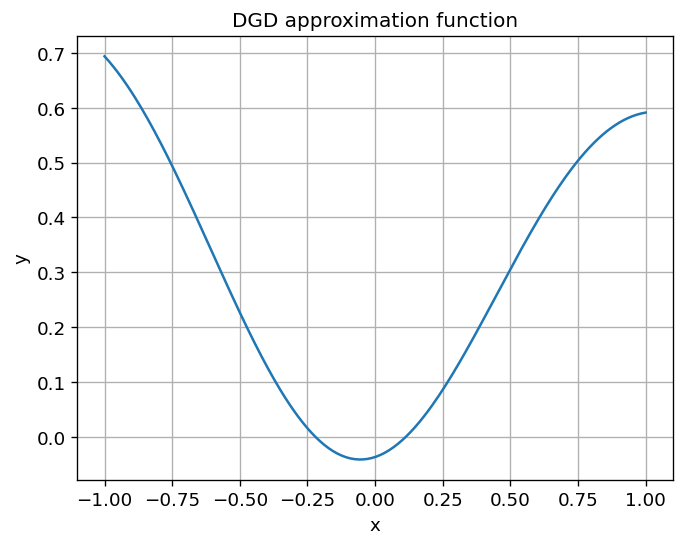

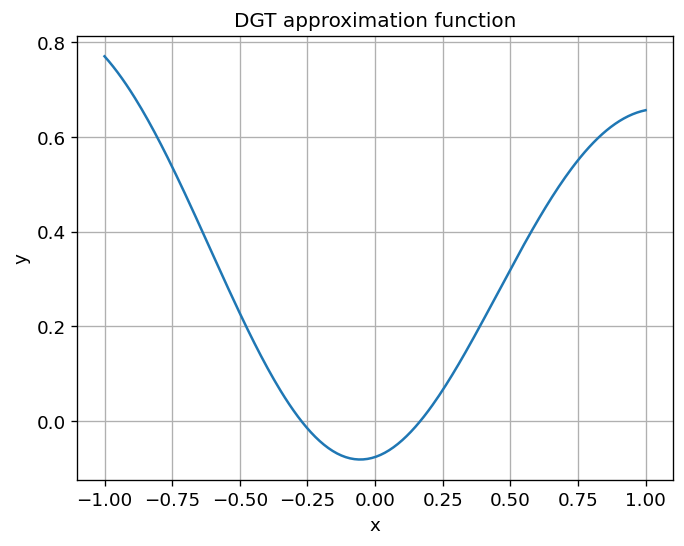

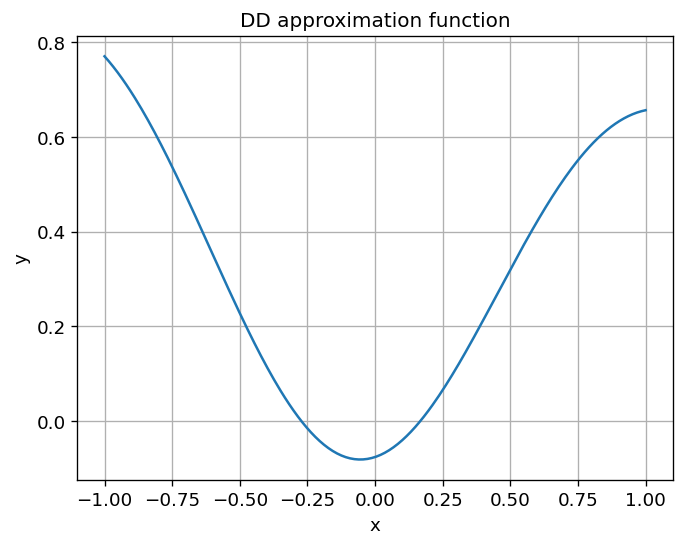

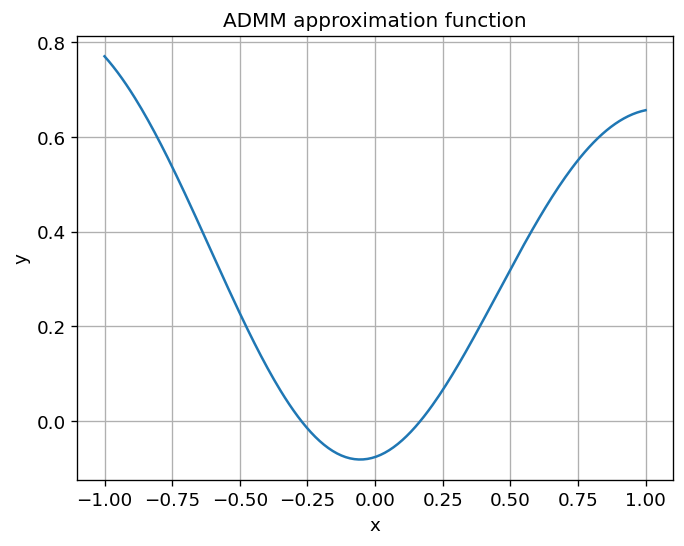

<Figure size 768x576 with 0 Axes>

In [14]:
nt      = 250
x_prime = np.linspace(-1, 1, nt)

# Figure 6a–d
for alpha_v, name, fname in [
        (alpha_DGD_,  'DGD approximation function',  'fig6a_func_DGD.pdf'),
        (alpha_DGT_,  'DGT approximation function',  'fig6b_func_DGT.pdf'),
        (alpha_DD_,   'DD approximation function',   'fig6c_func_DD.pdf'),
        (alpha_ADMM_, 'ADMM approximation function', 'fig6d_func_ADMM.pdf')]:
    plot_solution(alpha_v, x_prime, x_approx, name=name)
    plt.savefig(fname)


## 1.12 Impact of the total number of points $n$ — Figure 7

We increase to $n = 500$, $m = 23$, $a = 50$.
The exact $\alpha^*$ is no longer computed; we use the **objective value** as error metric.

> All methods converge to approximately the same objective value,
> confirming consistency at larger scale.


F* (n=500) = 59.0736
L = 146.6144,  μ = 0.02000
lr_DGD = 0.00535,  lr_DGT = 0.00334
σ_max²(B, line a=50) = 3.9961  →  lr_DD = 0.00901

Running algorithms (n=500)…
DGD  it=     0  error=2.9079e+03
DGD  it=   250  error=6.1919e+01
DGD  it=   500  error=5.9751e+01
DGD  it=   750  error=5.9273e+01
DGD  it=  1000  error=5.9167e+01
DGD  it=  1250  error=5.9143e+01
DGD  it=  1500  error=5.9135e+01
DGD  it=  1750  error=5.9131e+01
DGD  it=  2000  error=5.9128e+01
DGD  it=  2250  error=5.9125e+01
DGD  it=  2500  error=5.9122e+01
DGD  it=  2750  error=5.9119e+01
DGD  it=  3000  error=5.9117e+01
DGD  it=  3250  error=5.9114e+01
DGD  it=  3500  error=5.9112e+01
DGD  it=  3750  error=5.9110e+01
DGD  it=  4000  error=5.9108e+01
DGD  it=  4250  error=5.9106e+01
DGD  it=  4500  error=5.9105e+01
DGD  it=  4750  error=5.9103e+01
DGT  it=     0  error=6.1231e+03
DGT  it=   250  error=6.2747e+01
DGT  it=   500  error=6.0014e+01
DGT  it=   750  error=5.9339e+01
DGT  it=  1000  error=5.9171e+01
DGT  it=  12

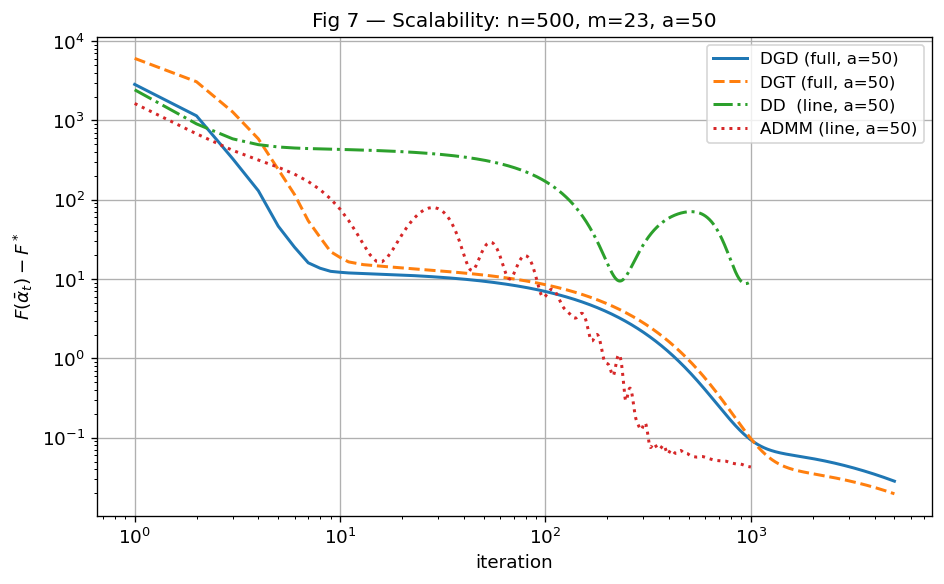

In [32]:
# ══════════════════════════════════════════════════════════════════════════
# Fig 7 — Scalability: n=500, m=23, a=50
# ══════════════════════════════════════════════════════════════════════════

np.random.seed(0)
n2, m2, a2 = 500, 23, 50
sigma2, nu2 = 0.5, 1.0

sel2        = range(n2)
n_a2        = int(n2 / a2)                                  # 10 pts/agent
approx_ind2 = np.random.choice(sel2, m2, replace=False)
device_ind2 = np.array(sel2).reshape(a2, n_a2)
indices2    = (approx_ind2, device_ind2)

x2        = x_full[list(sel2)]
y2        = y_full[list(sel2)]
K2        = get_kernel(x2, x2[approx_ind2])
K_mm2     = K2[approx_ind2, :]

# ── Centralised exact solution F* ─────────────────────────────────────────
# Normal equations: (σ²K_mm + K^T K + νI)α = K^T y
A_star2    = sigma2**2 * K_mm2 + K2.T @ K2 + nu2 * np.eye(m2)
alpha_star2 = np.linalg.solve(A_star2, K2.T @ y2)

def get_val2(alpha_val):
    """Global objective F(α) for n=500."""
    return (sigma2**2/2 * alpha_val @ K_mm2 @ alpha_val
            + 0.5 * np.linalg.norm(y2 - K2 @ alpha_val)**2
            + nu2/2 * alpha_val @ alpha_val)

F_star2 = get_val2(alpha_star2)
print(f"F* (n=500) = {F_star2:.4f}")

# ── Recompute L and μ for n=500 ──────────────────────────────────────────
L2_list, mu2_list = [], []
for i in range(a2):
    K_Am2 = K2[device_ind2[i], :]
    H_i2  = sigma2**2/a2 * K_mm2 + K_Am2.T @ K_Am2 + nu2/a2 * np.eye(m2)
    ev2   = np.linalg.eigvalsh(H_i2)
    L2_list.append(ev2.max()); mu2_list.append(ev2.min())

L2_smooth  = max(L2_list)
mu2_strong = min(mu2_list)
print(f"L = {L2_smooth:.4f},  μ = {mu2_strong:.5f}")

# ── Mixing matrix W for DGD/DGT (fully-connected, a=50) ──────────────────
L2_fc = np.full((a2, a2), -1.); np.fill_diagonal(L2_fc, a2 - 1)
tau2  = 1.0 / (1.0 + float(np.linalg.eigvalsh(L2_fc)[-1]))
W2    = np.eye(a2) - tau2 * L2_fc

eigs_W2 = np.sort(np.linalg.eigvalsh(W2))
rho2    = max(abs(eigs_W2[0]), abs(eigs_W2[-2]))

# Step-sizes
lr_dgd2 = 0.8 * (1 - rho2) / L2_smooth   # DGD: η < (1-ρ)/L
lr_dgt2 = 0.5 * (1 - rho2) / L2_smooth   # DGT: more conservative

# ── Line graph edge map for DD/ADMM (49 edges, feasible step-size) ────────
Edge_map_line2 = {i: (i, i + 1) for i in range(a2 - 1)}

# σ_max²(B^T B) for path graph P_{50}: = λ_max(L_line)
L_line2 = np.zeros((a2, a2))
for i in range(a2 - 1):
    L_line2[i, i]     += 1; L_line2[i+1, i+1] += 1
    L_line2[i, i+1]    = -1; L_line2[i+1, i]   = -1
sig_A2_line2 = float(np.linalg.eigvalsh(L_line2).max())
lr_dd2 = 0.9 * (2 * mu2_strong / sig_A2_line2)   # 90% of bound

print(f"lr_DGD = {lr_dgd2:.5f},  lr_DGT = {lr_dgt2:.5f}")
print(f"σ_max²(B, line a=50) = {sig_A2_line2:.4f}  →  lr_DD = {lr_dd2:.5f}")

# ── Run all four algorithms ───────────────────────────────────────────────
n_iter2     = 5000     # DGD / DGT
n_iter_dd2  = 1000     # DD / ADMM (inner sub-problem per outer iter)

params2_dgd = (W2,          K2, y2, sigma2, nu2)
params2_dd  = (Edge_map_line2, K2, y2, sigma2, nu2)

print("\nRunning algorithms (n=500)…")
_, raw_DGD  = DGD( params2_dgd, indices2, lr=lr_dgd2, n_iter=n_iter2,  metric='val')
_, raw_DGT  = DGT( params2_dgd, indices2, lr=lr_dgt2, n_iter=n_iter2,  metric='val')
_, raw_DD   = DD(  params2_dd,  indices2, lr=lr_dd2,  n_iter=n_iter_dd2,
                   lr_sub=5e-4, n_iter_sub=20, metric='val')
_, raw_ADMM = ADMM(params2_dd,  indices2, lr=lr_dd2,  n_iter=n_iter_dd2,
                   lr_sub=5e-4, n_iter_sub=20, BETA=10, metric='val')

# Convert raw F(α) → optimality gap F(α) − F*
err2_DGD  = raw_DGD  - F_star2
err2_DGT  = raw_DGT  - F_star2
err2_DD   = raw_DD   - F_star2
err2_ADMM = raw_ADMM - F_star2

print(f"Final gaps — DGD:{err2_DGD[-1]:.3e}  DGT:{err2_DGT[-1]:.3e}"
      f"  DD:{err2_DD[-1]:.3e}  ADMM:{err2_ADMM[-1]:.3e}")

# ── Figure 7 ──────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
for label, err, ls in [
    ('DGD (full, a=50)',      err2_DGD,  '-'),
    ('DGT (full, a=50)',      err2_DGT,  '--'),
    ('DD  (line, a=50)',      err2_DD,   '-.'),
    ('ADMM (line, a=50)',     err2_ADMM, ':'),
]:
    iters = np.arange(1, len(err) + 1)
    plt.loglog(iters, np.maximum(err, 1e-10), ls=ls, lw=1.8, label=label)

plt.xlabel('iteration')
plt.ylabel(r'$F(\bar\alpha_t) - F^*$')
plt.title(f'Fig 7 — Scalability: n={n2}, m={m2}, a={a2}')
plt.legend()
plt.tight_layout()
savefig('fig7_scalability_n500')
plt.show()


## 1.13 (Optional) Push-Sum DGD — convergence recovery on directed graphs

Standard DGD and DGT both require $W$ to be **doubly stochastic** (symmetric mixing).  
When the communication graph is directed and $A$ is only *column*-stochastic
(each agent distributes its full mass: $\sum_j A[j,i]=1$, but $\sum_i A[j,i]\neq 1$),
naïve DGD converges to a *biased* point that is not $\alpha^*$.

**Push-Sum protocol** recovers exact convergence  
by tracking an auxiliary weight $w_i^t$ alongside the state $x_i^t$:

$$x_i^{t+1} = \sum_j A[i,j]\,x_j^t - \eta\,\nabla f_i\!\left(\frac{x_i^t}{w_i^t}\right), \qquad
w_i^{t+1} = \sum_j A[i,j]\,w_j^t, \qquad
\tilde\alpha_i^t = \frac{x_i^t}{w_i^t}.$$

The weight $w_i^t$ converges to the $i$-th component of the Perron vector of $A$,
so dividing $x_i^t$ by $w_i^t$ exactly compensates the non-uniform mixing.

**Setup.** We use the directed graph below (5 agents, $d=0.6$ self-loop weight):

$$A = I\cdot d + (1-d)\cdot A_{\text{directed}},\quad
\text{edges: }0\!\to\!1,\;0\!\to\!3,\;1\!\to\!2,\;2\!\to\!3,\;3\!\to\!4,\;4\!\to\!0.$$

Agent 0 has **out-degree 2** (sends to 1 and 3), agent 3 has **in-degree 2**
(receives from 2 and 0): the in-/out-degree imbalance makes $A$ **non-doubly-stochastic**.

Column-stochastic mixing matrix A (directed):
[[0.6 0.  0.  0.  0.4]
 [0.2 0.6 0.  0.  0. ]
 [0.  0.4 0.6 0.  0. ]
 [0.2 0.  0.4 0.6 0. ]
 [0.  0.  0.  0.4 0.6]]
Col sums : [1. 1. 1. 1. 1.]  ← all 1  (column stochastic)
Row sums : [1.  0.8 1.  1.2 1. ]  ← NOT uniform (non-doubly-stochastic)
rho_2(A) = 0.7302  →  spectral gap = 0.2698
DGD  it=     0  error=1.8362e+00
DGD  it=  1000  error=7.7704e-01
DGD  it=  2000  error=4.9461e-01
DGD  it=  3000  error=3.4052e-01
DGD  it=  4000  error=2.5718e-01
DGD  it=  5000  error=2.1013e-01
DGD  it=  6000  error=1.8053e-01
DGD  it=  7000  error=1.5929e-01
DGD  it=  8000  error=1.4240e-01
DGD  it=  9000  error=1.2812e-01
DGD  it= 10000  error=1.1566e-01
DGD  it= 11000  error=1.0461e-01
DGD  it= 12000  error=9.4752e-02
DGD  it= 13000  error=8.5915e-02
DGD  it= 14000  error=7.7984e-02
DGD  it= 15000  error=7.0861e-02
DGD  it= 16000  error=6.4464e-02
DGD  it= 17000  error=5.8722e-02
DGD  it= 18000  error=5.3571e-02
DGD  it= 19000  error=4.8957e-02

Fin

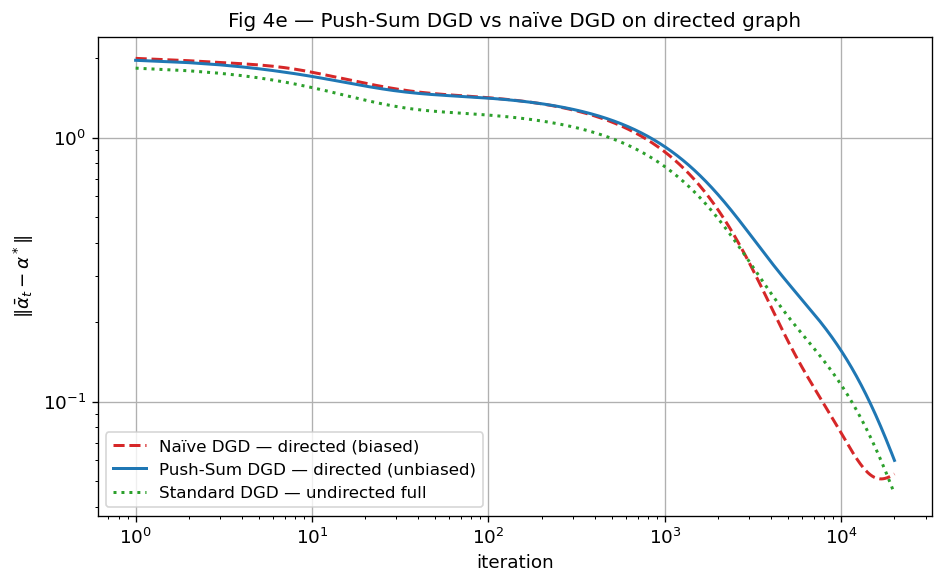

In [34]:
# ══════════════════════════════════════════════════════════════════════════
# (Optional) Push-Sum DGD — directed communication
# ══════════════════════════════════════════════════════════════════════════

d_ps     = 0.6                                    # self-loop weight
edges_ps = [(0,1),(0,3),(1,2),(2,3),(3,4),(4,0)]  # directed edges (no self-loops)
out_deg  = {0:2, 1:1, 2:1, 3:1, 4:1}             # out-degree (excl. self-loop)

A_ps = np.zeros((a, a))
for i in range(a):
    A_ps[i, i] = d_ps                                   # self-loop
for (i, j) in edges_ps:
    A_ps[j, i] = (1 - d_ps) / out_deg[i]               # forward edge

print("Column-stochastic mixing matrix A (directed):")
print(A_ps.round(3))
print(f"Col sums : {A_ps.sum(axis=0)}  ← all 1  (column stochastic)")
print(f"Row sums : {A_ps.sum(axis=1).round(3)}  ← NOT uniform (non-doubly-stochastic)")

eigs_ps = sorted(abs(np.linalg.eigvals(A_ps)), reverse=True)
rho2_ps = eigs_ps[1]
print(f"rho_2(A) = {rho2_ps:.4f}  →  spectral gap = {1-rho2_ps:.4f}")


# ── Algorithm 1: Push-Sum DGD (directed, unbiased) ────────────────────────
def DGD_push_sum(A_col, lr=5e-4, n_iter=20000, metric='gap'):
    """
    Push-Sum DGD  (Nedić & Ozdaglar 2010).

    Each agent i maintains:
      x_i^t  : "weighted state"  (NOT the iterate itself)
      w_i^t  : scalar weight     (tracks Perron-vector share)

    De-biased iterate:  alpha_i^t = x_i^t / w_i^t

    Update:
      x^{t+1} = A @ x^t  -  lr * grad_f(alpha^t)
      w^{t+1} = A @ w^t
      alpha^t = x^t / w^t          (de-biased, used for gradient)

    The weight w^t converges to the Perron vector of A, so the division
    compensates the non-uniform in-degree and recovers unbiased averaging.
    """
    m_  = params_c[0].shape[1]
    a_  = len(indices[1])

    x = np.array([np.random.rand(m_) for _ in range(a_)])   # shape (a, m)
    w = np.ones((a_, 1))                                      # shape (a, 1)

    error = np.zeros(n_iter)
    if metric == 'gap':
        alpha_exact = exact_solution(params_c, approx_ind)

    for k in range(n_iter):
        alpha_k = x / w                                       # de-biased iterate
        grad    = get_grad(alpha_k, params_c, indices)
        x = A_col @ x - lr * grad
        w = A_col @ w

        alpha_mean = np.mean(alpha_k, axis=0)
        error[k] = (np.linalg.norm(alpha_mean - alpha_exact) if metric == 'gap'
                    else get_val(alpha_mean, params_c, indices[0]))

    return x / w, error


# ── Algorithm 2: Naïve DGD on directed graph (biased, for contrast) ───────
def DGD_naive_directed(A_col, lr=5e-4, n_iter=20000, metric='gap'):
    """
    Standard DGD using the row-stochastic transpose A^T (no push-sum).
    On a non-doubly-stochastic directed graph this converges to a BIASED
    point: the residual gap does not vanish as lr → 0.
    """
    P   = A_col.T                                            # row-stochastic
    m_  = params_c[0].shape[1]
    a_  = len(indices[1])

    alpha = np.array([np.random.rand(m_) for _ in range(a_)])
    error = np.zeros(n_iter)
    if metric == 'gap':
        alpha_exact = exact_solution(params_c, approx_ind)

    for k in range(n_iter):
        grad  = get_grad(alpha, params_c, indices)
        alpha = P @ alpha - lr * grad
        alpha_mean = np.mean(alpha, axis=0)
        error[k] = (np.linalg.norm(alpha_mean - alpha_exact) if metric == 'gap'
                    else get_val(alpha_mean, params_c, indices[0]))

    return alpha, error


# ── Run the comparison ─────────────────────────────────────────────────────
np.random.seed(42)
lr_ps    = 5e-4    # same step-size for fair comparison
n_iter_ps = 20000

_, err_push_sum      = DGD_push_sum(      A_ps, lr=lr_ps, n_iter=n_iter_ps)
_, err_naive_dir     = DGD_naive_directed(A_ps, lr=lr_ps, n_iter=n_iter_ps)
# Reference: standard DGD on undirected fully-connected graph
_, err_dgd_ref       = DGD((W_full, K, y, sigma, nu), indices,
                           lr=lr_ps, n_iter=n_iter_ps, metric='gap')

print(f"\nFinal gap after {n_iter_ps} iterations (lr={lr_ps}):")
print(f"  Push-Sum DGD   (directed A)  : {err_push_sum[-1]:.4e}")
print(f"  Naïve DGD      (directed A)  : {err_naive_dir[-1]:.4e}")
print(f"  Standard DGD   (undirected)  : {err_dgd_ref[-1]:.4e}")


# ── Figure – convergence comparison ───────────────────────────────────────
plt.figure(figsize=(8, 5))
iters = np.arange(1, n_iter_ps + 1)
plt.loglog(iters, err_naive_dir,  label='Naïve DGD — directed (biased)',    lw=1.8, ls='--', color='C3')
plt.loglog(iters, err_push_sum,   label='Push-Sum DGD — directed (unbiased)',lw=1.8, ls='-',  color='C0')
plt.loglog(iters, err_dgd_ref,    label='Standard DGD — undirected full',    lw=1.8, ls=':',  color='C2')
plt.xlabel('iteration')
plt.ylabel(r'$\|\bar\alpha_t - \alpha^*\|$')
plt.title('Fig 4e — Push-Sum DGD vs naïve DGD on directed graph')
plt.legend()
plt.tight_layout()
savefig('fig4e_push_sum')
plt.show()

---
# Part II — Federated Learning

## 2.0 Background

We now work with the **second database** ($C = 5$ clients, 20 points each).
Nyström landmarks are fixed at $m = 10$ uniformly-spaced points in $[-1,1]$.

**FedAvg** performs $E$ local gradient steps per client per round, then averages models.
With large $E$ and non-IID data, **client drift** causes divergence.
**SCAFFOLD** corrects drift via per-client control variates.


$$F(\alpha)=\frac{1}{C}\sum_{i=1}^C F_i(\alpha),\quad
F_i(\alpha)=\frac{\sigma^2}{2C}\alpha^\top K_{mm}\alpha
+\frac{1}{2}\|y^{(i)}-K_m^{(i)}\alpha\|^2+\frac{\nu}{2C}\|\alpha\|^2.$$


## 2.1 Utility functions (Part II)

In [16]:
# ──────────────────────────────────────────────────────────────────────────
# Stochastic gradient (mini-batch B drawn per client)
# ──────────────────────────────────────────────────────────────────────────
def get_grad_fed(alpha, params, indices, devices=None):
    KERNELS, y, sigma, nu, C, B, E, m, S = params
    approx_ind, device_ind = indices
    C, m = alpha.shape
    if devices is None:
        devices = range(C)
    grad = np.zeros((len(devices), m))
    for i_, i in enumerate(devices):
        batch  = np.random.choice(20, B, replace=False)
        K_mm   = KERNELS[device_ind[i]][:m, :]
        K_Am   = KERNELS[device_ind[i]][batch, :]
        y_A    = np.array(y[device_ind[i]])[batch]
        alpha_i = alpha[i]
        grad[i_] = (sigma**2/5 * K_mm @ alpha_i
                    - K_Am.T @ (y_A - K_Am @ alpha_i)
                    + nu/5 * alpha_i)
    return grad


# ──────────────────────────────────────────────────────────────────────────
# Full-batch objective value
# ──────────────────────────────────────────────────────────────────────────
def get_val_fed(alpha_val, params, indices):
    KERNELS, ys, sigma, nu, C, B, E, m, S = params
    approx_ind, device_ind = indices
    val = 0.
    for i in range(len(device_ind)):
        K_mm = KERNELS[device_ind[i]][:m, :]
        K_all = KERNELS[device_ind[i]]
        y_all = np.array(ys[device_ind[i]])
        val += (sigma**2/10 * alpha_val @ K_mm @ alpha_val
                + 0.5 * np.linalg.norm(y_all - K_all @ alpha_val)**2
                + nu/10 * alpha_val @ alpha_val)
    return val


# ──────────────────────────────────────────────────────────────────────────
# Optimal objective value F*  (closed-form normal equations)
# ──────────────────────────────────────────────────────────────────────────
def suropt_val(params, indices):
    KERNELS, ys, sigma, nu, C, B, E, m, S = params
    approx_ind, device_ind = indices
    m_loc = KERNELS[0].shape[1]
    M, Bv = None, None
    for i in range(len(device_ind)):
        K     = KERNELS[device_ind[i]]
        K_mm  = K[:m_loc, :]
        y_i   = ys[device_ind[i]]
        tM    = sigma**2/5 * K_mm + K.T @ K + nu/5 * np.eye(m_loc)
        tb    = K.T @ y_i
        M  = tM if M  is None else M  + tM
        Bv = tb if Bv is None else Bv + tb
    alpha_opt = np.linalg.solve(M, Bv)
    return get_val_fed(alpha_opt, params, indices)


# ──────────────────────────────────────────────────────────────────────────
# Plot helper — matches all Part II figures in the report
# (x-axis: Iterations TE, y-axis: Objective Optimality Gap, log-log scale)
# ──────────────────────────────────────────────────────────────────────────
def plot_error_fed(errors, title='Error', savename=None):
    """
    Log-log plot aligned by the aggregation period E.

    Parameters
    ----------
    errors : dict  { label: (error_array, E_value) }
    """
    Es  = [E for _, E in errors.values()]
    ME  = max(Es)
    TE  = len(list(errors.values())[0][0])

    plt.figure(figsize=(9, 6), dpi=150)
    for name, (error, E) in errors.items():
        idx    = np.arange(0, len(error), ME)
        err    = error[idx]
        idx[0] = 1
        plt.loglog(idx, err, label=name)

    plt.xlabel('Iterations TE')
    plt.ylabel('Objective Optimality Gap')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.ylim(0.8e-6, 1.3e1)
    plt.xlim(1, TE * 1.1)
    plt.tight_layout()
    if savename:
        plt.savefig(savename)
    plt.show()


## 2.2 Algorithm implementations — FedAvg, FedAvg-diminishing, SCAFFOLD


In [17]:
# ══════════════════════════════════════════════════════════════════════════
# FedAvg — constant learning rate
# ══════════════════════════════════════════════════════════════════════════
def FedAvg(params, indices, lr=0.0001, n_iter=1000):
    """
    FedAvg (McMahan et al., 2017).

    Each round:
      1. Sample S clients uniformly at random.
      2. Each selected client takes one stochastic gradient step.
      3. Every E steps: average local models -> global model -> broadcast.

    With constant lr and non-IID data, *client drift* causes the local
    models to diverge when E is large.
    """
    KERNELS, y, sigma, nu, C, B, E, m, S = params
    opt_val = suropt_val(params, indices)
    Xg, Xc = np.zeros(m), np.zeros((C, m))
    error, mapper = np.zeros(n_iter), np.zeros(C)

    for T in range(n_iter):
        grad = get_grad_fed(Xc, params, indices)
        selected = np.random.choice(C, S, replace=False)
        mapper[selected] = 1.
        grad_S = mapper.reshape(-1, 1) * grad
        mapper = np.zeros(C)
        Xc -= lr * grad_S
        if T % E == 0:
            Xg  = Xc.mean(axis=0)
            Xc *= 0; Xc += Xg
        error[T] = np.abs(get_val_fed(Xg, params, indices) - opt_val)
        if T % (n_iter // 20) == 0:
            print(f'FedAvg      T={T:5d}  gap={error[T]:.4e}')

    return Xg, error


# ══════════════════════════════════════════════════════════════════════════
# FedAvg — diminishing learning rate  lr_t = lr0 / (0.0003*t + 1)
# ══════════════════════════════════════════════════════════════════════════
def FedAvg_diminishing(params, indices, lr=0.0001, n_iter=1000):
    """
    Same as FedAvg but with a diminishing step-size that removes the
    residual oscillation caused by a constant lr.
    """
    KERNELS, y, sigma, nu, C, B, E, m, S = params
    lr_init = lr
    opt_val = suropt_val(params, indices)
    Xg, Xc = np.zeros(m), np.zeros((C, m))
    error, mapper = np.zeros(n_iter), np.zeros(C)

    for T in range(n_iter):
        lr_t = lr_init / (0.0003 * T + 1)
        grad = get_grad_fed(Xc, params, indices)
        selected = np.random.choice(C, S, replace=False)
        mapper[selected] = 1.
        grad_S = mapper.reshape(-1, 1) * grad
        mapper = np.zeros(C)
        Xc -= lr_t * grad_S
        if T % E == 0:
            Xg  = Xc.mean(axis=0)
            Xc *= 0; Xc += Xg
        error[T] = np.abs(get_val_fed(Xg, params, indices) - opt_val)
        if T % (n_iter // 20) == 0:
            print(f'FedAvg-dim  T={T:5d}  gap={error[T]:.4e}')

    return Xg, error


# ══════════════════════════════════════════════════════════════════════════
# SCAFFOLD — corrects client drift via control variates
# ══════════════════════════════════════════════════════════════════════════
def SCAFFOLD(params, indices, lr=0.001, n_iter=1000, Xlr=0.1):
    """
    SCAFFOLD (Karimireddy et al., 2020).

    Maintains per-client control variates c_i and a global variate c.
    Corrected local update:
        X_c -= lr * (grad - c_c + c_g)

    After each sync:
        c_g  +=  mean(c_c_new - c_c)
        c_c   =  c_c_new

    This prevents client drift even with large E and non-IID data.

    Parameters
    ----------
    Xlr : server aggregation step-size (global model update rate)
    """
    KERNELS, y, sigma, nu, C, B, E, m, S = params
    opt_val = suropt_val(params, indices)

    Xg, Yg = np.zeros(m), np.zeros(m)
    Xc, Yc = np.zeros((C, m)), np.zeros(m)
    Cc      = np.zeros((C, m))
    Xc_start = Xc.copy()
    Cc_plus  = get_grad_fed(Xc_start, params, indices)

    error, mapper = np.zeros(n_iter), np.zeros(C)

    for T in range(n_iter):
        grad = get_grad_fed(Xc, params, indices)
        selected = np.random.choice(C, S, replace=False)
        mapper[selected] = 1.
        grad_S = mapper.reshape(-1, 1) * grad
        mapper = np.zeros(C)

        Xc -= lr * (grad_S - Cc + Yg)       # corrected local step

        if T % E == 0:
            DXc      = Xc - Xc_start
            DYc      = Cc_plus - Cc
            Cc       = Cc_plus.copy()
            Xg      += Xlr * DXc.mean(axis=0)
            Xc       = Xc * 0 + Xg
            Yg      += DYc.mean(axis=0)
            Yc *= 0; Yc += Yg
            Xc_start = Xc.copy()
            Cc_plus  = get_grad_fed(Xc_start, params, indices)

        error[T] = np.abs(get_val_fed(Xg, params, indices) - opt_val)
        if T % (n_iter // 20) == 0:
            print(f'SCAFFOLD    T={T:5d}  gap={error[T]:.4e}')

    return Xg, error


## 2.3 Dataset and kernel construction

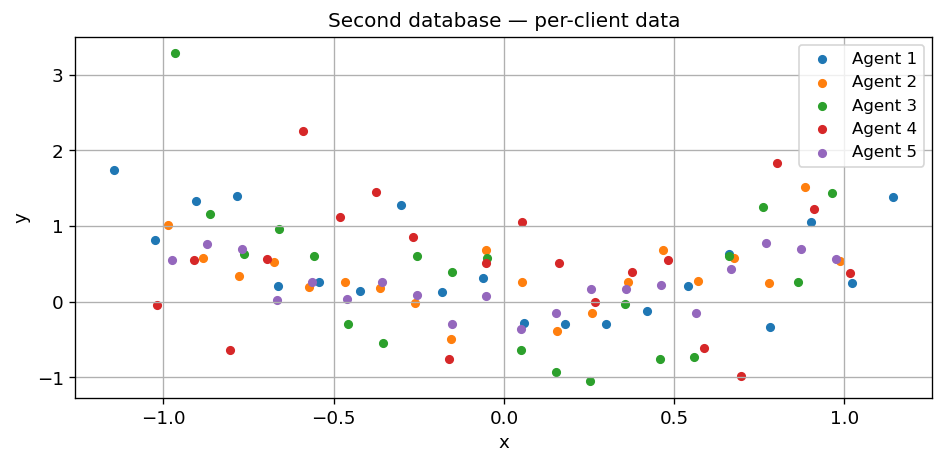

In [18]:
with open('second_database.pkl', 'rb') as f:
    X_db2, Y_db2 = pickle.load(f)

C_fed = len(X_db2)   # 5 clients
m_fed = 10           # Nystrom size

# Fixed landmarks: m uniformly spaced points in [-1, 1]
x_lm = np.linspace(-1, 1, m_fed)

# KERNELS_fed[i] shape = (20, m_fed)
# K[row, col] = k(x_data_i[row], x_landmark[col])
# First m_fed rows serve as K_mm block; all 20 rows as K_Am block.
KERNELS_fed = []
for i in range(C_fed):
    xi  = np.array(X_db2[i])
    K_i = np.array([[np.exp(-(xr - xc)**2) for xc in x_lm] for xr in xi])
    KERNELS_fed.append(K_i)

approx_ind_fed = np.arange(m_fed)
device_ind_fed = np.arange(C_fed)
indices_fed    = (approx_ind_fed, device_ind_fed)

sigma_fed, nu_fed = 0.5, 1.0
n_iter_fed, B_fed = 10000, 20

# Plot per-client data distribution
plt.figure(figsize=(8, 4))
for i in range(C_fed):
    plt.scatter(X_db2[i], Y_db2[i], s=20, label=f'Agent {i+1}')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Second database — per-client data')
plt.legend(); plt.tight_layout(); plt.show()


## 2.4 FedAvg — constant learning rate, $E \in \{1, 5, 50\}$ — Figure 8

**Setup:** $B = 20$, $S = C = 5$, $\eta = 0.002$.

> $E = 1$ reduces to standard DGD and converges cleanly.
> $E = 5$ and $E = 50$ exhibit oscillatory behaviour due to client drift.


FedAvg      T=    0  gap=1.0948e+01
FedAvg      T=  500  gap=3.6067e-01
FedAvg      T= 1000  gap=3.8280e-02
FedAvg      T= 1500  gap=1.4190e-02
FedAvg      T= 2000  gap=8.1819e-03
FedAvg      T= 2500  gap=4.9736e-03
FedAvg      T= 3000  gap=3.0451e-03
FedAvg      T= 3500  gap=1.8707e-03
FedAvg      T= 4000  gap=1.1533e-03
FedAvg      T= 4500  gap=7.1395e-04
FedAvg      T= 5000  gap=4.4422e-04
FedAvg      T= 5500  gap=2.7808e-04
FedAvg      T= 6000  gap=1.7537e-04
FedAvg      T= 6500  gap=1.1156e-04
FedAvg      T= 7000  gap=7.1705e-05
FedAvg      T= 7500  gap=4.6635e-05
FedAvg      T= 8000  gap=3.0737e-05
FedAvg      T= 8500  gap=2.0559e-05
FedAvg      T= 9000  gap=1.3971e-05
FedAvg      T= 9500  gap=9.6516e-06
FedAvg      T=    0  gap=1.0948e+01
FedAvg      T=  500  gap=3.6648e-01
FedAvg      T= 1000  gap=3.9614e-02
FedAvg      T= 1500  gap=1.4413e-02
FedAvg      T= 2000  gap=8.1733e-03
FedAvg      T= 2500  gap=4.9307e-03
FedAvg      T= 3000  gap=3.0118e-03
FedAvg      T= 3500  gap=1.8

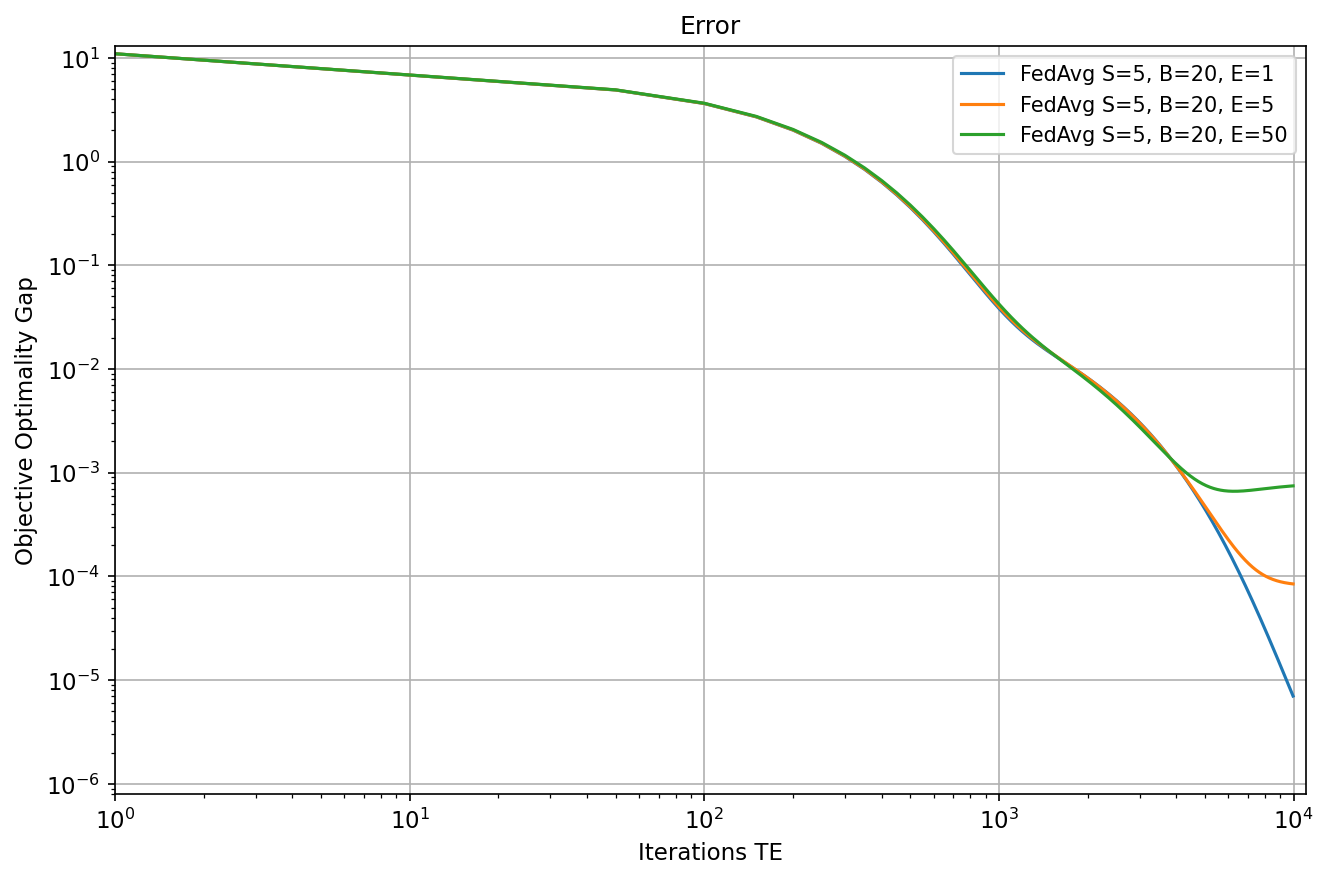

In [19]:
errors_fig8 = {}
for E_val in [1, 5, 50]:
    params_f = (KERNELS_fed, Y_db2, sigma_fed, nu_fed, C_fed, B_fed,
                E_val, m_fed, C_fed)
    _, err = FedAvg(params_f, indices_fed, lr=0.002, n_iter=n_iter_fed)
    errors_fig8[f'FedAvg S={C_fed}, B={B_fed}, E={E_val}'] = (err, E_val)

# Figure 8
plot_error_fed(errors_fig8, title='Error', savename='fig8_fedavg_constant.pdf')


## 2.5 FedAvg — diminishing learning rate — Figure 9

The schedule $\eta_t = \eta_0 / (0.0003\,T + 1)$ stabilises convergence:
all $E$ values now track each other closely.


FedAvg-dim  T=    0  gap=1.0948e+01
FedAvg-dim  T=  500  gap=4.3580e-01
FedAvg-dim  T= 1000  gap=5.9461e-02
FedAvg-dim  T= 1500  gap=2.1272e-02
FedAvg-dim  T= 2000  gap=1.3068e-02
FedAvg-dim  T= 2500  gap=9.3971e-03
FedAvg-dim  T= 3000  gap=7.1127e-03
FedAvg-dim  T= 3500  gap=5.5309e-03
FedAvg-dim  T= 4000  gap=4.3862e-03
FedAvg-dim  T= 4500  gap=3.5352e-03
FedAvg-dim  T= 5000  gap=2.8893e-03
FedAvg-dim  T= 5500  gap=2.3906e-03
FedAvg-dim  T= 6000  gap=1.9996e-03
FedAvg-dim  T= 6500  gap=1.6889e-03
FedAvg-dim  T= 7000  gap=1.4391e-03
FedAvg-dim  T= 7500  gap=1.2360e-03
FedAvg-dim  T= 8000  gap=1.0693e-03
FedAvg-dim  T= 8500  gap=9.3126e-04
FedAvg-dim  T= 9000  gap=8.1596e-04
FedAvg-dim  T= 9500  gap=7.1894e-04
FedAvg-dim  T=    0  gap=1.0948e+01
FedAvg-dim  T=  500  gap=4.4168e-01
FedAvg-dim  T= 1000  gap=6.1155e-02
FedAvg-dim  T= 1500  gap=2.1730e-02
FedAvg-dim  T= 2000  gap=1.3169e-02
FedAvg-dim  T= 2500  gap=9.3884e-03
FedAvg-dim  T= 3000  gap=7.0707e-03
FedAvg-dim  T= 3500  gap=5.4

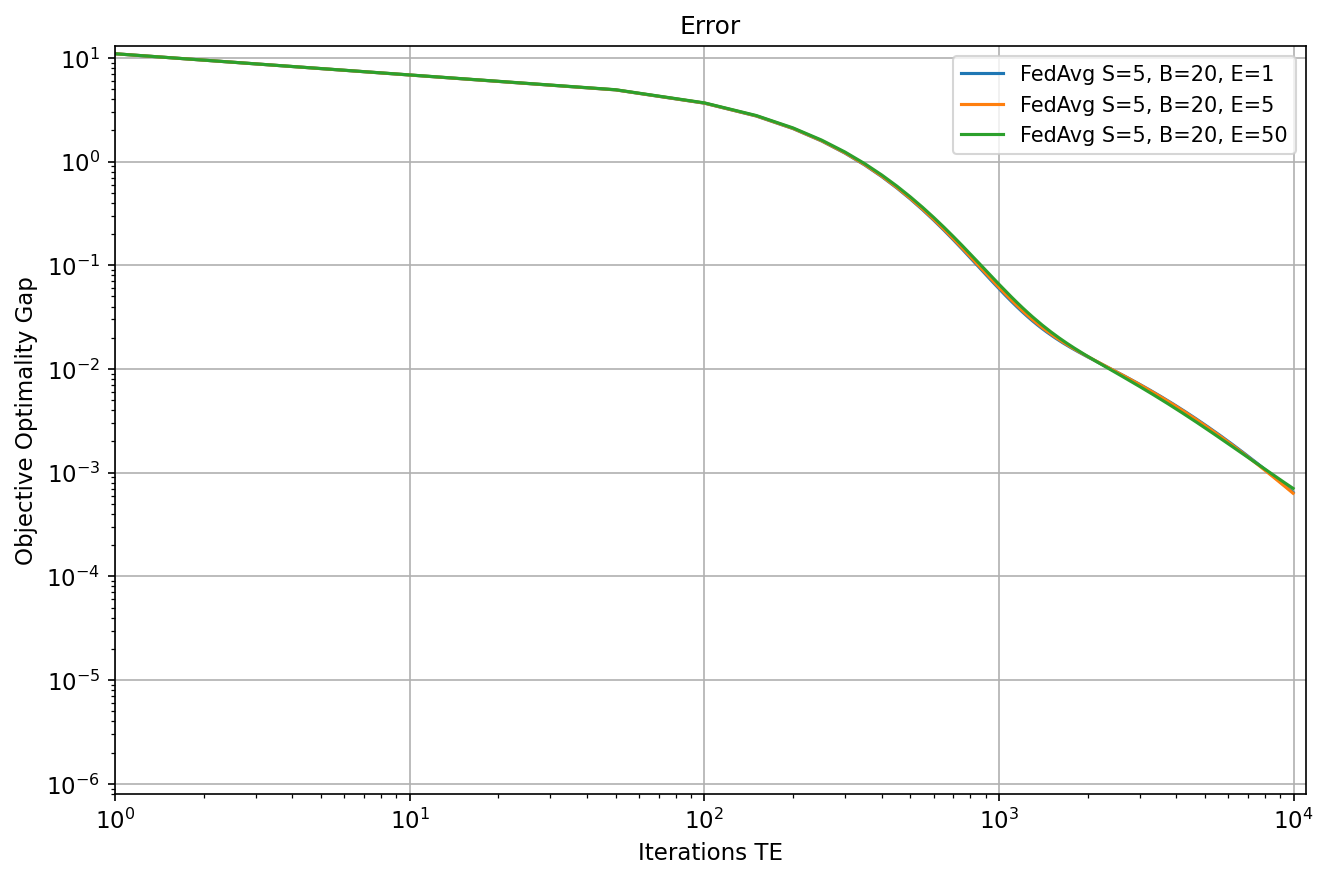

In [20]:
errors_fig9 = {}
for E_val in [1, 5, 50]:
    params_f = (KERNELS_fed, Y_db2, sigma_fed, nu_fed, C_fed, B_fed,
                E_val, m_fed, C_fed)
    _, err = FedAvg_diminishing(params_f, indices_fed, lr=0.002, n_iter=n_iter_fed)
    errors_fig9[f'FedAvg S={C_fed}, B={B_fed}, E={E_val}'] = (err, E_val)

# Figure 9
plot_error_fed(errors_fig9, title='Error', savename='fig9_fedavg_diminishing.pdf')


## 2.6 FedAvg — reduced batch size $B = 15$ — Figure 10

Reducing to $B = 15$ introduces stochasticity; the error plateaus near $10^{-1}$.


FedAvg      T=    0  gap=1.1441e+01
FedAvg      T=  500  gap=8.0113e-01
FedAvg      T= 1000  gap=1.5347e-01
FedAvg      T= 1500  gap=6.9784e-02
FedAvg      T= 2000  gap=4.4753e-02
FedAvg      T= 2500  gap=2.8499e-02
FedAvg      T= 3000  gap=3.3064e-02
FedAvg      T= 3500  gap=3.2179e-02
FedAvg      T= 4000  gap=2.0227e-02
FedAvg      T= 4500  gap=2.0198e-02
FedAvg      T= 5000  gap=2.1373e-02
FedAvg      T= 5500  gap=1.6973e-02
FedAvg      T= 6000  gap=2.1241e-02
FedAvg      T= 6500  gap=2.8580e-02
FedAvg      T= 7000  gap=2.0959e-02
FedAvg      T= 7500  gap=1.5680e-02
FedAvg      T= 8000  gap=1.5460e-02
FedAvg      T= 8500  gap=1.5448e-02
FedAvg      T= 9000  gap=2.1246e-02
FedAvg      T= 9500  gap=1.4426e-02
FedAvg      T=    0  gap=1.1409e+01
FedAvg      T=  500  gap=7.9755e-01
FedAvg      T= 1000  gap=1.5069e-01
FedAvg      T= 1500  gap=7.1796e-02
FedAvg      T= 2000  gap=4.3633e-02
FedAvg      T= 2500  gap=5.5322e-02
FedAvg      T= 3000  gap=2.2907e-02
FedAvg      T= 3500  gap=2.6

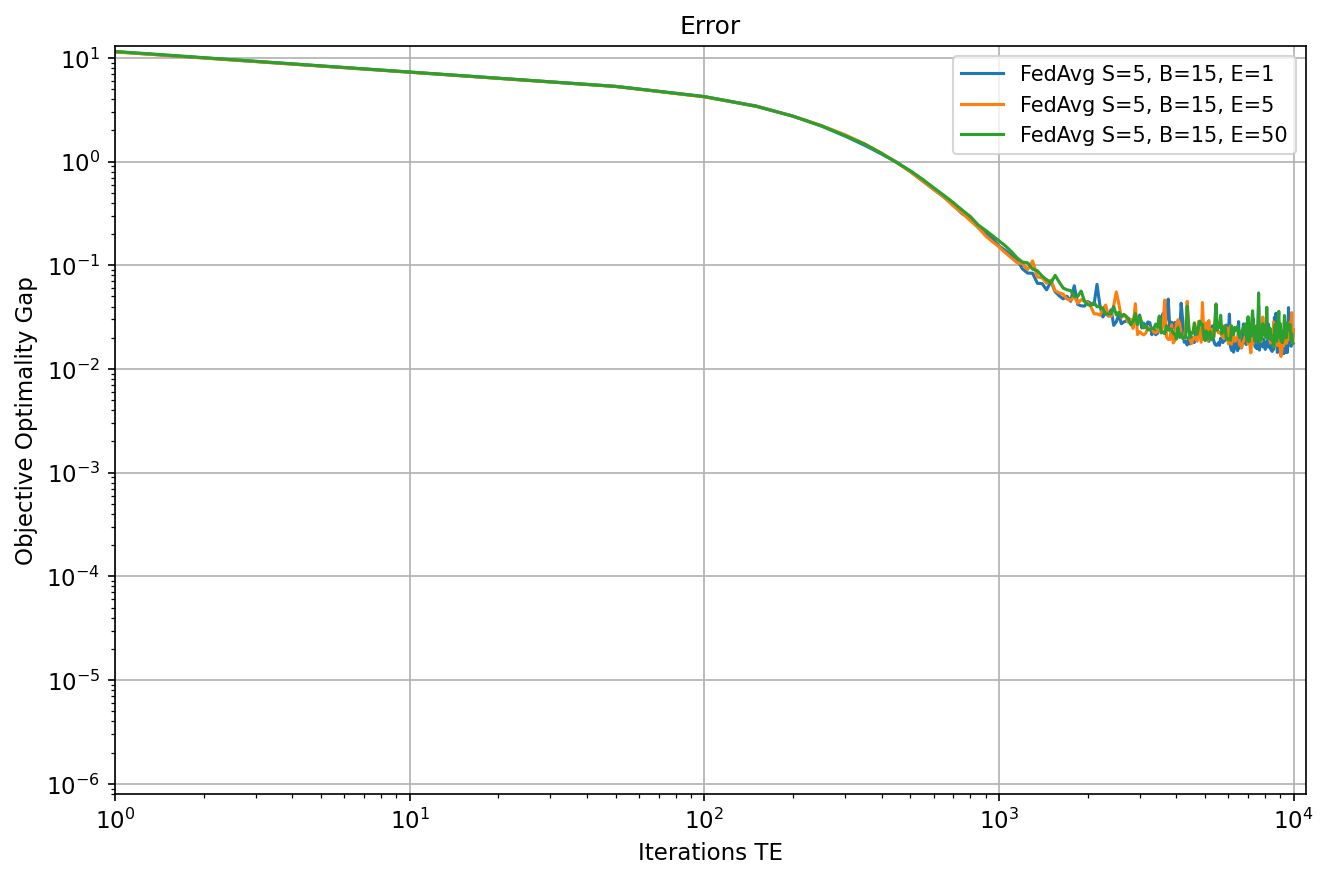

In [21]:
errors_fig10 = {}
for E_val in [1, 5, 50]:
    params_f = (KERNELS_fed, Y_db2, sigma_fed, nu_fed, C_fed, 15,
                E_val, m_fed, C_fed)
    _, err = FedAvg(params_f, indices_fed, lr=0.002, n_iter=n_iter_fed)
    errors_fig10[f'FedAvg S={C_fed}, B=15, E={E_val}'] = (err, E_val)

# Figure 10
plot_error_fed(errors_fig10, title='Error', savename='fig10_fedavg_B15.pdf')


## 2.7 FedAvg — $B = 15$, $S = 3$ clients — Figure 11

Further stochasticity from partial client participation ($S = 3$ out of 5).
Convergence trends remain similar to $S = 5$.


FedAvg      T=    0  gap=1.1787e+01
FedAvg      T=  500  gap=1.7858e+00
FedAvg      T= 1000  gap=5.4750e-01
FedAvg      T= 1500  gap=1.8966e-01
FedAvg      T= 2000  gap=1.0130e-01
FedAvg      T= 2500  gap=6.6185e-02
FedAvg      T= 3000  gap=4.4871e-02
FedAvg      T= 3500  gap=3.2998e-02
FedAvg      T= 4000  gap=2.4282e-02
FedAvg      T= 4500  gap=2.0978e-02
FedAvg      T= 5000  gap=4.2776e-02
FedAvg      T= 5500  gap=6.4003e-02
FedAvg      T= 6000  gap=1.9712e-02
FedAvg      T= 6500  gap=1.8929e-02
FedAvg      T= 7000  gap=1.8307e-02
FedAvg      T= 7500  gap=2.4168e-02
FedAvg      T= 8000  gap=4.2901e-02
FedAvg      T= 8500  gap=5.9504e-02
FedAvg      T= 9000  gap=1.6738e-02
FedAvg      T= 9500  gap=4.7290e-02
FedAvg      T=    0  gap=1.1669e+01
FedAvg      T=  500  gap=1.7404e+00
FedAvg      T= 1000  gap=4.9647e-01
FedAvg      T= 1500  gap=1.8508e-01
FedAvg      T= 2000  gap=1.0509e-01
FedAvg      T= 2500  gap=5.3413e-02
FedAvg      T= 3000  gap=6.6082e-02
FedAvg      T= 3500  gap=3.5

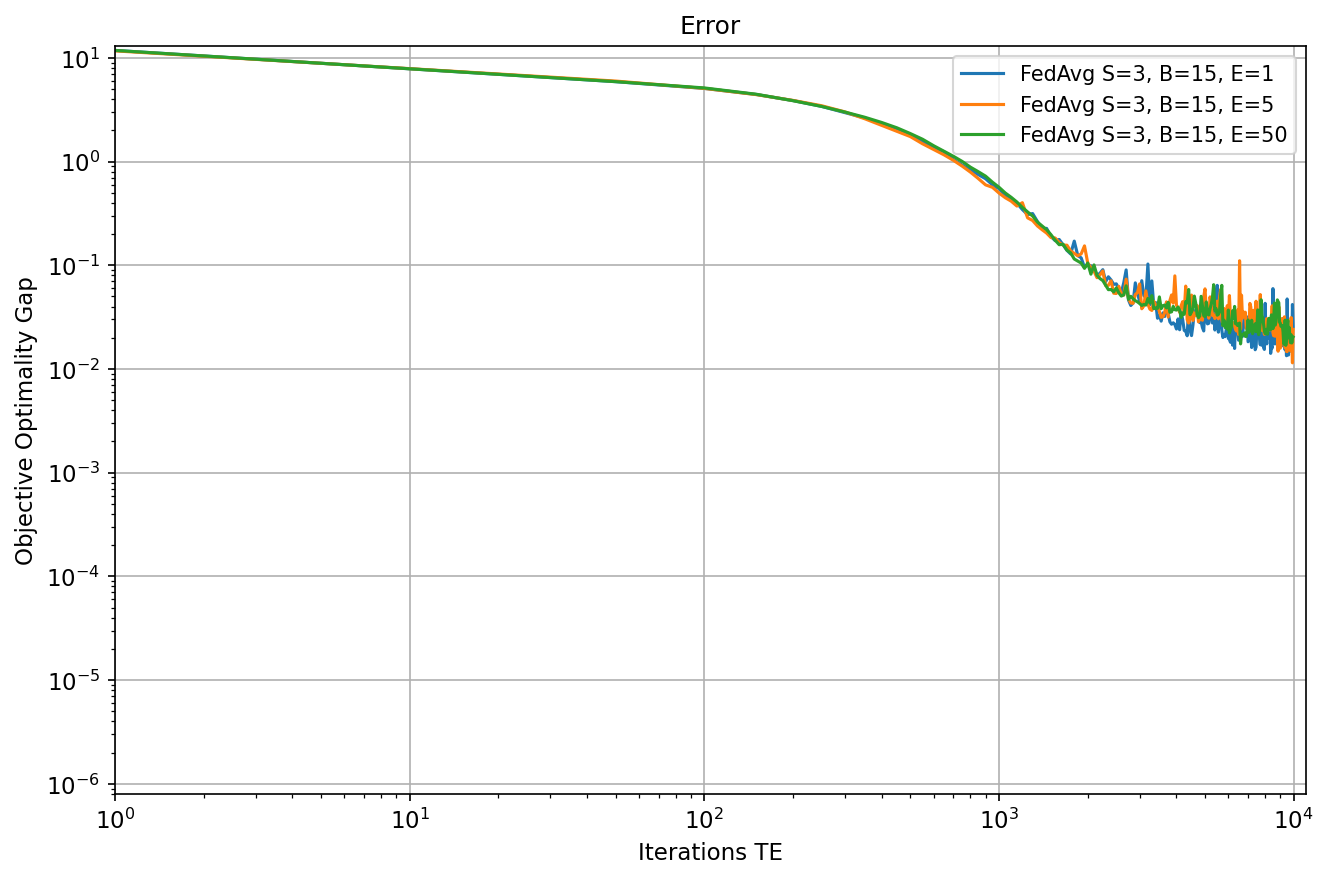

In [22]:
errors_fig11 = {}
for E_val in [1, 5, 50]:
    params_f = (KERNELS_fed, Y_db2, sigma_fed, nu_fed, C_fed, 15,
                E_val, m_fed, 3)
    _, err = FedAvg(params_f, indices_fed, lr=0.002, n_iter=n_iter_fed)
    errors_fig11[f'FedAvg S=3, B=15, E={E_val}'] = (err, E_val)

# Figure 11
plot_error_fed(errors_fig11, title='Error', savename='fig11_fedavg_B15_S3.pdf')


## 2.8 SCAFFOLD vs FedAvg — full batch, $B = 20$, $S = 5$ — Figure 12

SCAFFOLD with $\eta = 0.02$ and $\gamma = 0.2$ converges faster and to a
lower error than FedAvg, especially for $E = 50$.


FedAvg      T=    0  gap=1.0948e+01
FedAvg      T=  500  gap=3.6067e-01
FedAvg      T= 1000  gap=3.8280e-02
FedAvg      T= 1500  gap=1.4190e-02
FedAvg      T= 2000  gap=8.1819e-03
FedAvg      T= 2500  gap=4.9736e-03
FedAvg      T= 3000  gap=3.0451e-03
FedAvg      T= 3500  gap=1.8707e-03
FedAvg      T= 4000  gap=1.1533e-03
FedAvg      T= 4500  gap=7.1395e-04
FedAvg      T= 5000  gap=4.4422e-04
FedAvg      T= 5500  gap=2.7808e-04
FedAvg      T= 6000  gap=1.7537e-04
FedAvg      T= 6500  gap=1.1156e-04
FedAvg      T= 7000  gap=7.1705e-05
FedAvg      T= 7500  gap=4.6635e-05
FedAvg      T= 8000  gap=3.0737e-05
FedAvg      T= 8500  gap=2.0559e-05
FedAvg      T= 9000  gap=1.3971e-05
FedAvg      T= 9500  gap=9.6516e-06
SCAFFOLD    T=    0  gap=9.6217e+00
SCAFFOLD    T=  500  gap=3.8010e-02
SCAFFOLD    T= 1000  gap=8.1688e-03
SCAFFOLD    T= 1500  gap=3.0399e-03
SCAFFOLD    T= 2000  gap=1.1511e-03
SCAFFOLD    T= 2500  gap=4.4328e-04
SCAFFOLD    T= 3000  gap=1.7497e-04
SCAFFOLD    T= 3500  gap=7.1

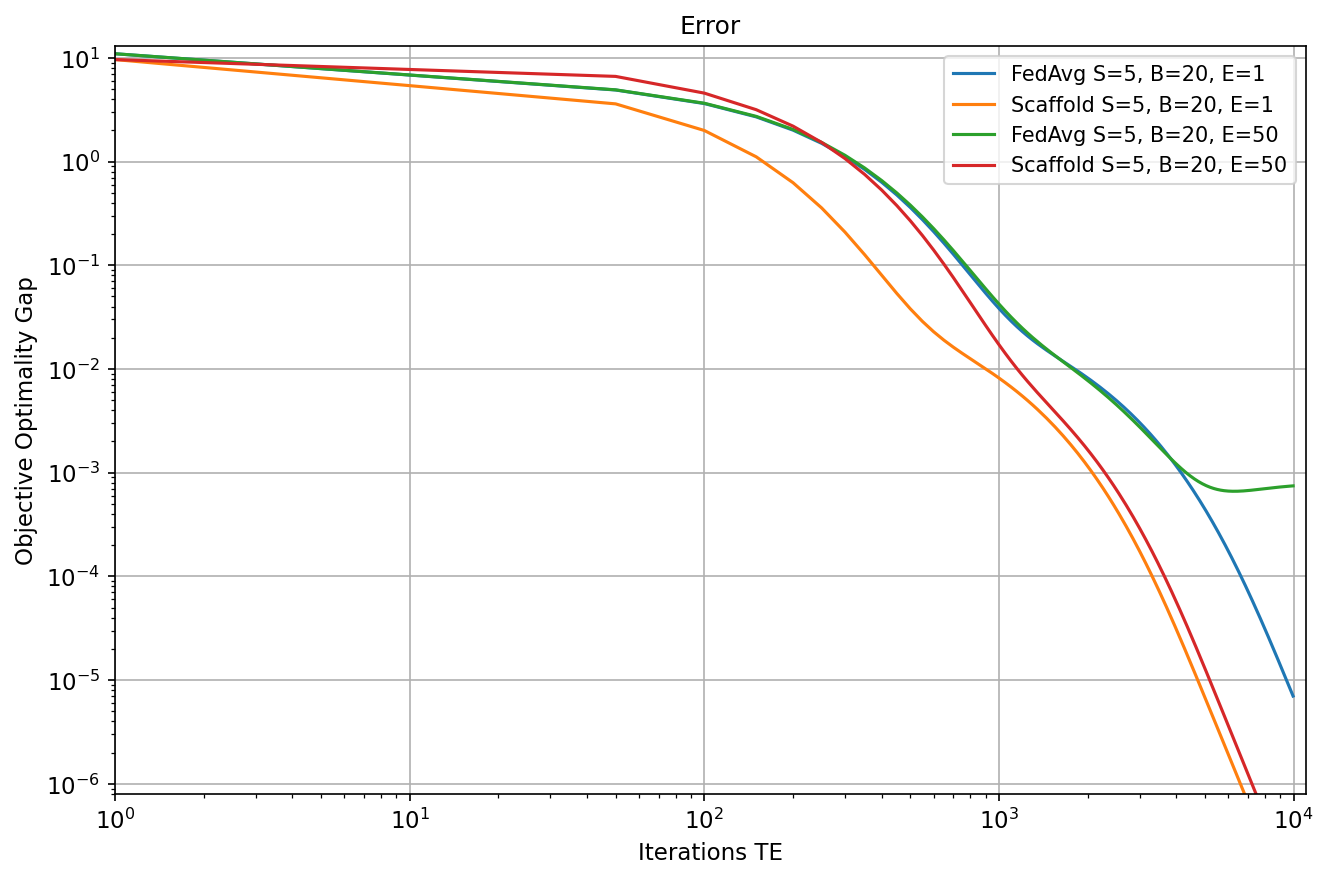

In [23]:
errors_fig12 = {}
for E_val in [1, 50]:
    # FedAvg
    params_f = (KERNELS_fed, Y_db2, sigma_fed, nu_fed, C_fed, B_fed,
                E_val, m_fed, C_fed)
    _, err_fa = FedAvg(params_f, indices_fed, lr=0.002, n_iter=n_iter_fed)
    errors_fig12[f'FedAvg S={C_fed}, B={B_fed}, E={E_val}'] = (err_fa, E_val)
    # SCAFFOLD
    _, err_sc = SCAFFOLD(params_f, indices_fed, lr=0.02, n_iter=n_iter_fed, Xlr=0.2)
    errors_fig12[f'Scaffold S={C_fed}, B={B_fed}, E={E_val}'] = (err_sc, E_val)

# Figure 12
plot_error_fed(errors_fig12, title='Error', savename='fig12_scaffold_full.pdf')


## 2.9 SCAFFOLD vs FedAvg — $B = 15$, $S = 3$ — Figure 13

In a more stochastic environment, SCAFFOLD's advantage diminishes because
increased noise masks the benefit of the control variate.


FedAvg      T=    0  gap=1.1879e+01
FedAvg      T=  500  gap=1.7740e+00
FedAvg      T= 1000  gap=5.4460e-01
FedAvg      T= 1500  gap=2.1305e-01
FedAvg      T= 2000  gap=9.1461e-02
FedAvg      T= 2500  gap=5.8952e-02
FedAvg      T= 3000  gap=4.7792e-02
FedAvg      T= 3500  gap=3.7333e-02
FedAvg      T= 4000  gap=4.9418e-02
FedAvg      T= 4500  gap=3.9034e-02
FedAvg      T= 5000  gap=2.8808e-02
FedAvg      T= 5500  gap=2.2748e-02
FedAvg      T= 6000  gap=2.1905e-02
FedAvg      T= 6500  gap=3.0829e-02
FedAvg      T= 7000  gap=5.5481e-02
FedAvg      T= 7500  gap=1.6879e-02
FedAvg      T= 8000  gap=2.6248e-02
FedAvg      T= 8500  gap=4.1517e-02
FedAvg      T= 9000  gap=1.6755e-02
FedAvg      T= 9500  gap=2.0355e-02
SCAFFOLD    T=    0  gap=1.1215e+01
SCAFFOLD    T=  500  gap=5.9219e-01
SCAFFOLD    T= 1000  gap=1.1045e-01
SCAFFOLD    T= 1500  gap=5.8461e-02
SCAFFOLD    T= 2000  gap=2.9473e-02
SCAFFOLD    T= 2500  gap=2.9743e-02
SCAFFOLD    T= 3000  gap=6.4645e-02
SCAFFOLD    T= 3500  gap=2.9

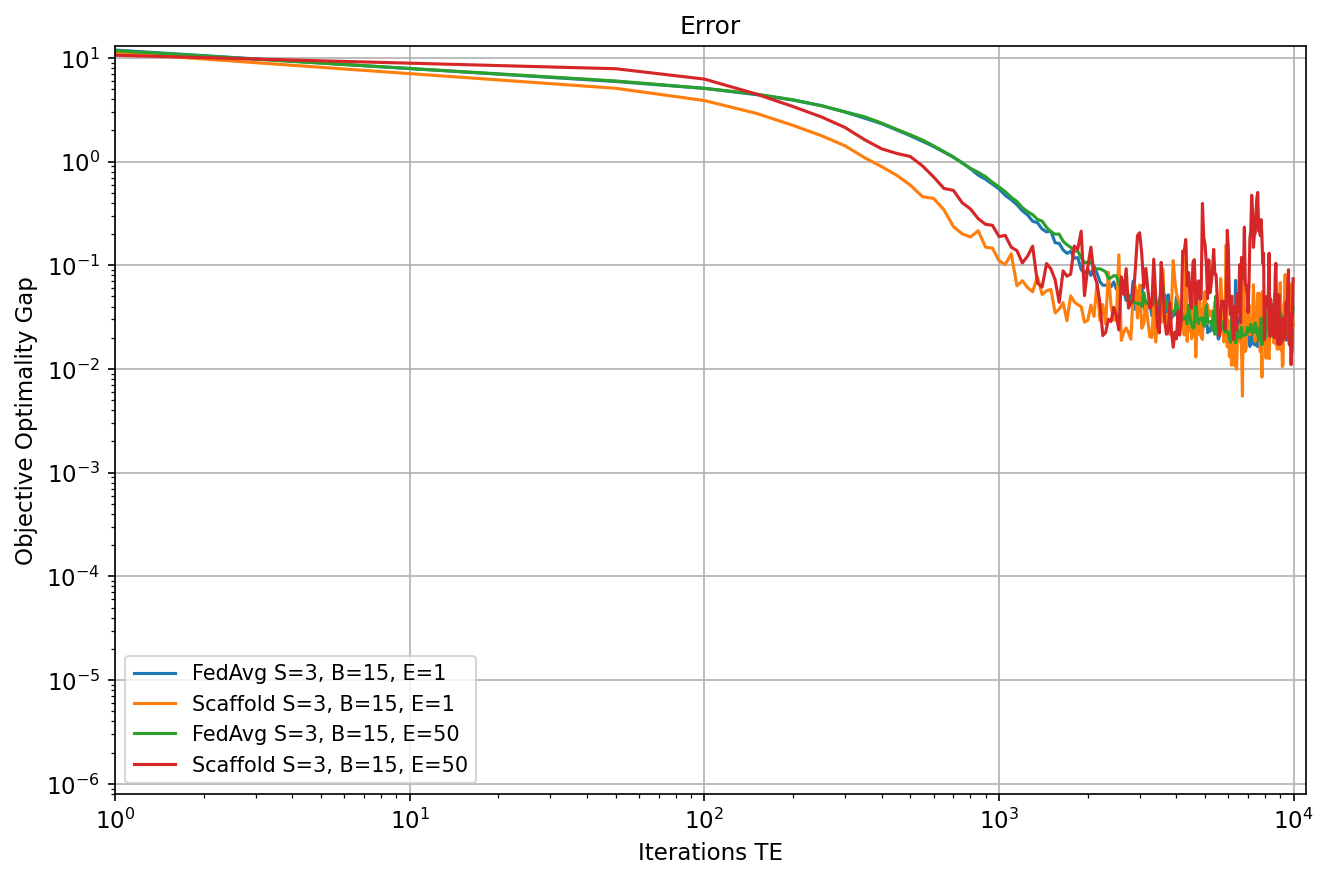

In [24]:
errors_fig13 = {}
for E_val in [1, 50]:
    params_f = (KERNELS_fed, Y_db2, sigma_fed, nu_fed, C_fed, 15,
                E_val, m_fed, 3)
    _, err_fa = FedAvg(params_f, indices_fed, lr=0.002, n_iter=n_iter_fed)
    _, err_sc = SCAFFOLD(params_f, indices_fed, lr=0.02, n_iter=n_iter_fed, Xlr=0.2)
    errors_fig13[f'FedAvg S=3, B=15, E={E_val}']   = (err_fa, E_val)
    errors_fig13[f'Scaffold S=3, B=15, E={E_val}'] = (err_sc, E_val)

# Figure 13
plot_error_fed(errors_fig13, title='Error', savename='fig13_scaffold_stoch.pdf')


## 2.10 Non-IID scenario — Figure 14


FedAvg      T=    0  gap=9.5066e+00
FedAvg      T= 1500  gap=4.8470e-01
FedAvg      T= 3000  gap=8.4252e-02
FedAvg      T= 4500  gap=4.1293e-02
FedAvg      T= 6000  gap=3.3796e-02
FedAvg      T= 7500  gap=3.2149e-02
FedAvg      T= 9000  gap=3.1741e-02
FedAvg      T=10500  gap=3.1628e-02
FedAvg      T=12000  gap=3.1594e-02
FedAvg      T=13500  gap=3.1585e-02
FedAvg      T=15000  gap=3.1583e-02
FedAvg      T=16500  gap=3.1585e-02
FedAvg      T=18000  gap=3.1587e-02
FedAvg      T=19500  gap=3.1588e-02
FedAvg      T=21000  gap=3.1590e-02
FedAvg      T=22500  gap=3.1591e-02
FedAvg      T=24000  gap=3.1592e-02
FedAvg      T=25500  gap=3.1592e-02
FedAvg      T=27000  gap=3.1593e-02
FedAvg      T=28500  gap=3.1593e-02
SCAFFOLD    T=    0  gap=9.7546e+00
SCAFFOLD    T= 1500  gap=9.4628e-01
SCAFFOLD    T= 3000  gap=1.3530e-01
SCAFFOLD    T= 4500  gap=2.1865e-02
SCAFFOLD    T= 6000  gap=5.1004e-03
SCAFFOLD    T= 7500  gap=2.0986e-03
SCAFFOLD    T= 9000  gap=1.2484e-03
SCAFFOLD    T=10500  gap=8.4

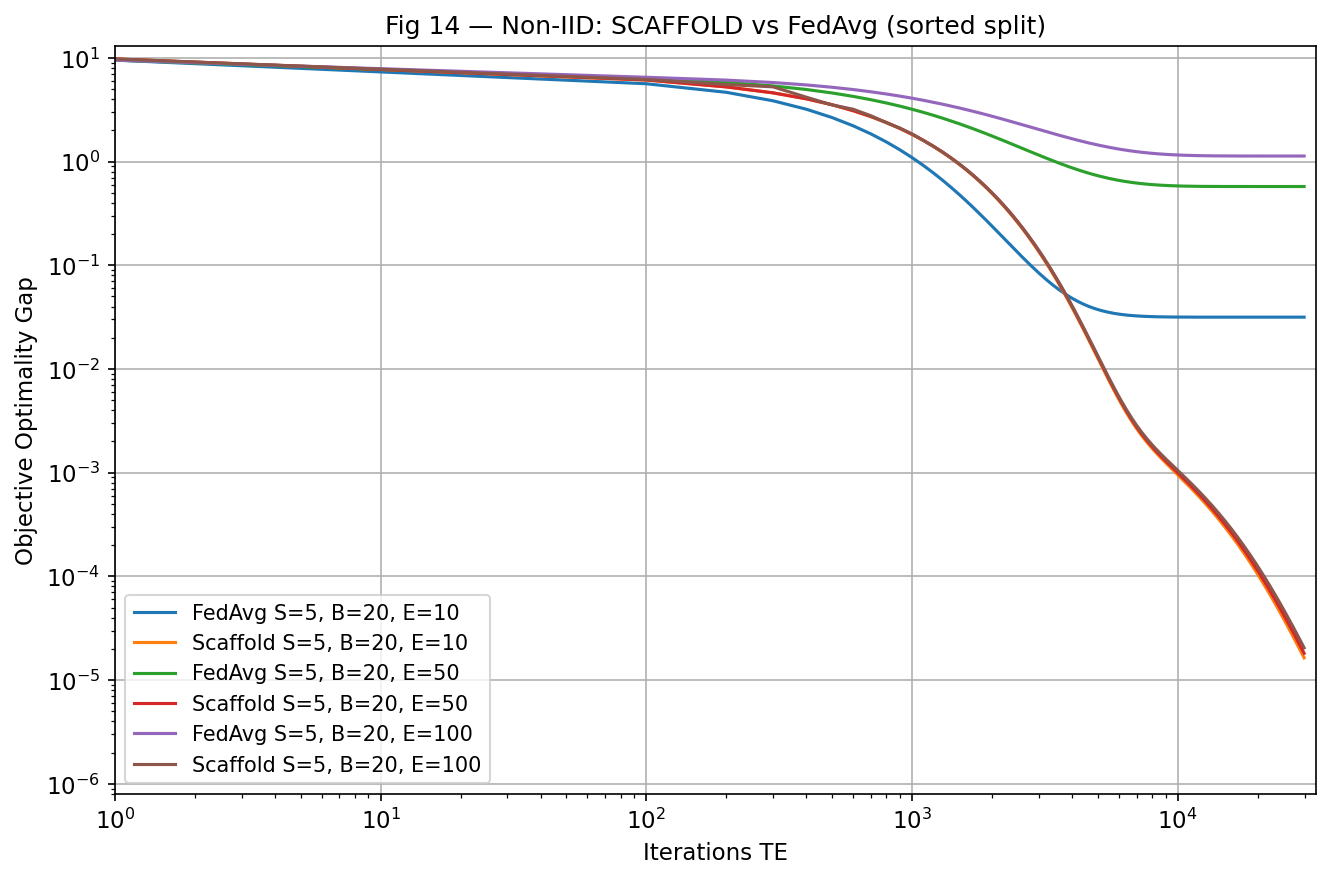

In [33]:
# Build the extreme non-IID split from first_database
sort_idx = np.argsort(x_full[:100])
x_sorted = x_full[sort_idx]
y_sorted = y_full[sort_idx]

X_niid = [x_sorted[i*20:(i+1)*20] for i in range(C_fed)]
Y_niid = [list(y_sorted[i*20:(i+1)*20]) for i in range(C_fed)]

KERNELS_niid = []
for i in range(C_fed):
    xi  = np.array(X_niid[i])
    K_i = np.array([[np.exp(-(xr - xc)**2) for xc in x_lm] for xr in xi])
    KERNELS_niid.append(K_i)

errors_fig14 = {}
n_iter14 = 30000
for E_val in [10, 50, 100]:
    params_n = (KERNELS_niid, Y_niid, sigma_fed, nu_fed, C_fed, B_fed,
                E_val, m_fed, C_fed)
    _, err_fa = FedAvg(   params_n, indices_fed,
                          lr=0.001,  n_iter=n_iter14)           
    _, err_sc = SCAFFOLD( params_n, indices_fed,
                          lr=0.005,  n_iter=n_iter14, Xlr=0.1)  
    errors_fig14[f'FedAvg S={C_fed}, B={B_fed}, E={E_val}']   = (err_fa, E_val)
    errors_fig14[f'Scaffold S={C_fed}, B={B_fed}, E={E_val}'] = (err_sc, E_val)

# Figure 14
plot_error_fed(errors_fig14, title='Fig 14 — Non-IID: SCAFFOLD vs FedAvg (sorted split)',
               savename='fig14_noniid.pdf')


---
# Part III — Differentially-Private DGD (DGD-DP)

## 3.0 Background


We return to the first database and solve the regression problem in a
**distributed and differentially-private** manner using DGD-DP.

Laplace noise $\xi^k \sim \mathrm{Lap}(0, b_k)$ is added to the shared state,
with noise scale calibrated to achieve $\varepsilon$-differential privacy
(Theorem 2, part 3 of arXiv:2202.01113):

$$b_k = \frac{0.01}{\varepsilon}\cdot\frac{1}{1+0.001\,k^{0.1}}, \qquad
\gamma_k = \frac{1}{1+0.001\,k^{0.9}}, \qquad
\eta_k   = \frac{0.002}{1+0.001\,k}.$$

The update rule is:
$$\alpha^{k+1} = \alpha^k
+ \gamma_k \hat{W}(\alpha^k + \xi^k)
- \gamma_k \operatorname{diag}(\hat{W})\xi^k
- \eta_k \nabla f(\alpha^k), \quad \hat{W} = W - I.$$

**Trade-off:** smaller $\varepsilon$ = stronger privacy = more noise = slower convergence.


## 3.1 DGD-DP implementation

In [26]:
def DGD_DP(params, indices, eps, n_iter=1000):
    """
    Differentially-Private Decentralised Gradient Descent.

    Parameters
    ----------
    params  : (W, K, y, sigma, nu)
    indices : (approx_ind, device_ind)
    eps     : privacy budget  (small eps = strong privacy = more noise)
    n_iter  : iterations

    Returns
    -------
    alpha : (a, m)    final iterate
    error : (n_iter,) optimality gap ||mean(alpha_t) - alpha*||
    """
    m = params[1].shape[1]
    a = len(indices[1])
    W, params_ = params[0], params[1:]
    W_hat = W - np.eye(a)

    # ── time-varying schedules (Theorem 2, part 3) ────────────────────────
    ks    = np.arange(1, n_iter + 1, dtype=float)
    gamma = 1. / (1. + 0.001 * ks**0.9)
    lr    = 0.002 / (1. + 0.001 * ks)
    b     = (0.01 / eps) / (1. + 0.001 * ks**0.1)   # Laplace noise scale

    alpha = np.array([np.random.rand(m) for _ in range(a)])
    error = np.zeros(n_iter)
    alpha_exact = exact_solution(params_, indices[0])

    for k in range(n_iter):
        grad  = get_grad(alpha, params_, indices)
        xi    = np.random.laplace(0., b[k], (a, m))   # privacy noise

        alpha += (gamma[k] * W_hat @ (alpha + xi)
                  - gamma[k] * np.diag(W_hat).reshape(a, 1) * xi
                  - lr[k] * grad)

        alpha_mean = np.mean(alpha, axis=0)
        error[k]   = np.linalg.norm(alpha_mean - alpha_exact)

        if k % (n_iter // 20) == 0:
            print(f'DGD-DP  eps={eps:.1f}  it={k:5d}  error={error[k]:.4e}')

    return alpha, error


## 3.2 Setup — $n=100$, $m=10$, $a=5$ — Figure 15

DGD-DP  eps=10.0  it=    0  error=1.8305e+00
DGD-DP  eps=10.0  it= 1000  error=5.0499e-01
DGD-DP  eps=10.0  it= 2000  error=3.3655e-01
DGD-DP  eps=10.0  it= 3000  error=2.7439e-01
DGD-DP  eps=10.0  it= 4000  error=2.3793e-01
DGD-DP  eps=10.0  it= 5000  error=2.1691e-01
DGD-DP  eps=10.0  it= 6000  error=1.9621e-01
DGD-DP  eps=10.0  it= 7000  error=1.9189e-01
DGD-DP  eps=10.0  it= 8000  error=1.8567e-01
DGD-DP  eps=10.0  it= 9000  error=1.8622e-01
DGD-DP  eps=10.0  it=10000  error=1.7983e-01
DGD-DP  eps=10.0  it=11000  error=1.7358e-01
DGD-DP  eps=10.0  it=12000  error=1.6597e-01
DGD-DP  eps=10.0  it=13000  error=1.5854e-01
DGD-DP  eps=10.0  it=14000  error=1.5224e-01
DGD-DP  eps=10.0  it=15000  error=1.4838e-01
DGD-DP  eps=10.0  it=16000  error=1.4518e-01
DGD-DP  eps=10.0  it=17000  error=1.4046e-01
DGD-DP  eps=10.0  it=18000  error=1.4151e-01
DGD-DP  eps=10.0  it=19000  error=1.4128e-01
DGD-DP  eps=1.0  it=    0  error=1.8312e+00
DGD-DP  eps=1.0  it= 1000  error=6.3650e-01
DGD-DP  eps=

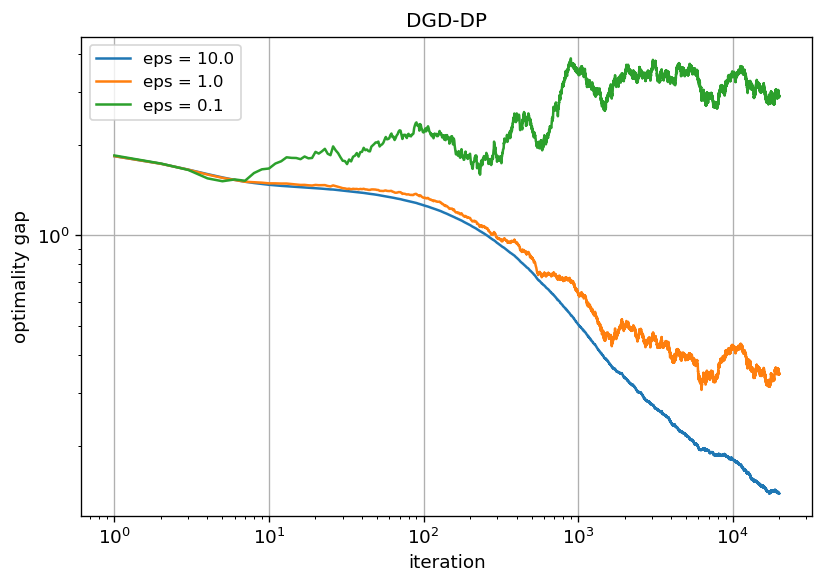

In [27]:
np.random.seed(42)

# Reuse first_database; rebuild with a fresh seed for Part III
n3, m3, a3    = 100, 10, 5
sigma3, nu3   = 0.5, 1.0

sel3        = range(n3)
n_a3        = int(n3 / a3)
approx_ind3 = np.random.choice(sel3, m3, replace=False)
device_ind3 = np.array(sel3).reshape(a3, n_a3)
indices3    = (approx_ind3, device_ind3)

x3 = x_full[list(sel3)];  y3 = y_full[list(sel3)]
x_approx3 = x3[approx_ind3]
K3 = get_kernel(x3, x_approx3)

# Fully-connected mixing matrix — correct formula via eigvalsh
L3 = np.full((a3, a3), -1.); np.fill_diagonal(L3, a3-1)
tau3 = 1.0 / (1.0 + float(np.linalg.eigvalsh(L3)[-1]))
W3 = np.eye(a3) - tau3 * L3

params_dp = (W3, K3, y3, sigma3, nu3)
eps_vals  = [10., 1., 0.1]
n_iter_dp = 20000

# Run DGD-DP for each epsilon
error_dp_list = []
for eps in eps_vals:
    np.random.seed(42)
    alpha_dp, err_dp = DGD_DP(params_dp, indices3, eps=eps, n_iter=n_iter_dp)
    error_dp_list.append(err_dp)

# Figure 15 — optimality gap vs iterations, all epsilon values
plt.figure(figsize=(7, 5))
for eps, err in zip(eps_vals, error_dp_list):
    plt.loglog(np.arange(1, n_iter_dp + 1), err, label=f'eps = {eps}')
plt.xlabel('iteration')
plt.ylabel('optimality gap')
plt.title('DGD-DP')
plt.legend()
plt.tight_layout()
plt.savefig('fig15_dgd_dp_n100.pdf')
plt.show()


## 3.3 Larger setting — $n=1000$, $m=33$, $a=100$ — Figure 16

For $\varepsilon = 10$: algorithm behaves like standard DGD (negligible noise).  
For $\varepsilon = 0.1$: divergence due to excessive noise injection.


DGD-DP  eps=10.0  it=    0  error=2.1814e+00
DGD-DP  eps=10.0  it= 1000  error=6.3640e-01
DGD-DP  eps=10.0  it= 2000  error=6.3020e-01
DGD-DP  eps=10.0  it= 3000  error=6.2617e-01
DGD-DP  eps=10.0  it= 4000  error=6.2483e-01
DGD-DP  eps=10.0  it= 5000  error=6.2313e-01
DGD-DP  eps=10.0  it= 6000  error=6.1793e-01
DGD-DP  eps=10.0  it= 7000  error=6.1656e-01
DGD-DP  eps=10.0  it= 8000  error=6.1343e-01
DGD-DP  eps=10.0  it= 9000  error=6.1067e-01
DGD-DP  eps=10.0  it=10000  error=6.1022e-01
DGD-DP  eps=10.0  it=11000  error=6.0850e-01
DGD-DP  eps=10.0  it=12000  error=6.0749e-01
DGD-DP  eps=10.0  it=13000  error=6.0660e-01
DGD-DP  eps=10.0  it=14000  error=6.0571e-01
DGD-DP  eps=10.0  it=15000  error=6.0628e-01
DGD-DP  eps=10.0  it=16000  error=6.0579e-01
DGD-DP  eps=10.0  it=17000  error=6.0560e-01
DGD-DP  eps=10.0  it=18000  error=6.0457e-01
DGD-DP  eps=10.0  it=19000  error=6.0363e-01
DGD-DP  eps=1.0  it=    0  error=2.1781e+00
DGD-DP  eps=1.0  it= 1000  error=6.4879e-01
DGD-DP  eps=

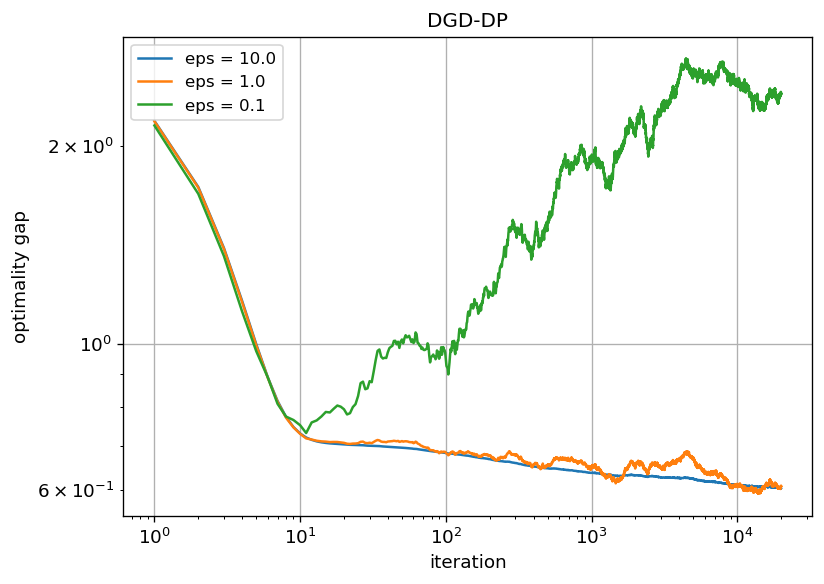

In [28]:
np.random.seed(0)
n4, m4, a4  = 1000, 33, 100
sigma4, nu4 = 0.5, 1.0

sel4        = range(n4)
n_a4        = int(n4 / a4)
approx_ind4 = np.random.choice(sel4, m4, replace=False)
device_ind4 = np.array(sel4).reshape(a4, n_a4)
indices4    = (approx_ind4, device_ind4)

x4 = x_full[list(sel4)];  y4 = y_full[list(sel4)]
x_approx4 = x4[approx_ind4]
K4 = get_kernel(x4, x_approx4)

L4 = np.full((a4, a4), -1.); np.fill_diagonal(L4, a4-1)
tau4 = 1.0 / (1.0 + float(np.linalg.eigvalsh(L4)[-1]))
W4 = np.eye(a4) - tau4 * L4

params_dp4   = (W4, K4, y4, sigma4, nu4)
n_iter_dp4   = 20000

error_dp4_list = []
for eps in eps_vals:
    np.random.seed(0)
    _, err_dp4 = DGD_DP(params_dp4, indices4, eps=eps, n_iter=n_iter_dp4)
    error_dp4_list.append(err_dp4)

# Figure 16
plt.figure(figsize=(7, 5))
for eps, err in zip(eps_vals, error_dp4_list):
    plt.loglog(np.arange(1, n_iter_dp4 + 1), err, label=f'eps = {eps}')
plt.xlabel('iteration')
plt.ylabel('optimality gap')
plt.title('DGD-DP')
plt.legend()
plt.tight_layout()
plt.savefig('fig16_dgd_dp_n1000.pdf')
plt.show()
